# BAB 4 — ANALISIS SARIMA VILLA BALI
## Prediksi Tingkat Hunian (Occupancy) | Canggu & Seminyak

## 1. Import Library & Konfigurasi

In [5]:
# Core
import os, warnings, time, itertools, ast
import numpy as np
import pandas as pd

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.signal import periodogram as scipy_periodogram

# Statsmodels
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf as sm_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

try:
    from pmdarima import auto_arima
    print('pmdarima tersedia')
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pmdarima', '-q'])
    from pmdarima import auto_arima
    print('pmdarima berhasil diinstall')

# Sklearn
from sklearn.metrics import mean_squared_error

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 5),
                     'axes.titlesize': 13, 'axes.labelsize': 11})

BASE_PATH = 'data/raw'

VILLA_CONFIG = {
    'briana_villas'  : {'area': 'canggu',   'color': '#3D6BE8'},
    'castello_villas': {'area': 'canggu',   'color': '#7c3aed'},
    'elina_villas'   : {'area': 'canggu',   'color': '#059669'},
    'isola_villas'   : {'area': 'canggu',   'color': '#db2777'},
    'eindra_villas'  : {'area': 'seminyak', 'color': '#d97706'},
    'esha_villas'    : {'area': 'seminyak', 'color': '#b45309'},
    'ozamiz_villas'  : {'area': 'seminyak', 'color': '#9333ea'},
}

print(f'Library & konfigurasi selesai. Total villa: {len(VILLA_CONFIG)}')

pmdarima tersedia
Library & konfigurasi selesai. Total villa: 7


## 2. Helper Functions

In [6]:
from pathlib import Path

if not os.path.exists(BASE_PATH):
    print(f'BASE_PATH tidak ditemukan: {BASE_PATH}')
else:
    migrated = list(Path(BASE_PATH).rglob('*.csv.migrated'))
    if migrated:
        for f in migrated:
            f.rename(f.with_suffix(''))
        print(f'{len(migrated)} file di-rename (.csv.migrated -> .csv)')
    print(f'BASE_PATH OK: {BASE_PATH}')

def build_path(area, villa, data_type):
    prefix = villa.replace('_villas', '_villa')
    fname  = f'{prefix}_daily_{data_type}.csv'
    return os.path.join(BASE_PATH, area, villa, fname)

def load_raw(path):
    try:
        df = pd.read_csv(path, sep=None, engine='python', encoding='utf-8-sig')
        df.columns = df.columns.str.strip()
        return df
    except FileNotFoundError:
        print(f'  File tidak ditemukan: {path}')
        return None

def parse_villa_date(series):
    s = series.astype(str).str.strip()
    parsed = pd.to_datetime(s, errors='coerce', dayfirst=True)
    if parsed.isna().mean() > 0.3:
        s = s.str.replace(r'^(Sun|Mon|Tue|Wed|Thu|Fri|Sat)\s+', '', regex=True).str.strip()
        parsed = pd.to_datetime(s, errors='coerce', dayfirst=True)
    return parsed

def parse_occupancy_to_percentage(series):
    s = series.astype(str).str.strip()
    if s.str.contains('%').any():
        result = pd.to_numeric(s.str.replace('%', '', regex=False).str.strip(), errors='coerce')
    else:
        result = pd.to_numeric(s, errors='coerce')
    if result.dropna().max() <= 1.0:
        result = result * 100.0
    return result.clip(0, 100)

def calculate_smape(actual, predicted):
    actual    = np.array(actual, dtype=float)
    predicted = np.array(predicted, dtype=float)
    denom     = (np.abs(actual) + np.abs(predicted)) / 2.0
    denom     = np.where(denom == 0, 1.0, denom)
    return float(np.mean(np.abs(actual - predicted) / denom) * 100)

def calculate_rmse(actual, predicted):
    return float(np.sqrt(mean_squared_error(actual, predicted)))

print('Helper functions loaded.')

BASE_PATH OK: data/raw
Helper functions loaded.


## 3. Load & Clean Data

In [ ]:
def seasonal_median_impute(series, window_months=1):
    s = series.copy()
    for idx in s[s.isna()].index:
        month = idx.month
        candidates = []
        for m_off in range(-window_months, window_months + 1):
            target_month = ((month - 1 + m_off) % 12) + 1
            same_month = s[(s.index.month == target_month) & ~s.isna()]
            candidates.extend(same_month.values.tolist())
        if candidates:
            s[idx] = np.median(candidates)
        else:
            s[idx] = s.median()
    return s

def clean_occupancy(df, villa_name):
    sep = '=' * 65
    df = df.copy()
    print(f'\n{sep}')
    print(f'[{villa_name}]  shape={df.shape}')

    date_cands = [c for c in df.columns if any(k in c.lower() for k in ['date','tanggal','tgl'])]
    date_col   = date_cands[0] if date_cands else df.columns[0]

    occ_exact = [c for c in df.columns if c.lower().strip() == 'occupancy']
    occ_kw    = [c for c in df.columns
                 if any(k in c.lower() for k in ['occ','hunian','occupied']) and c not in occ_exact]
    occ_col   = (occ_exact + occ_kw)[0] if (occ_exact + occ_kw) else None

    use_computed = False
    if occ_col is None:
        booked_c = [c for c in df.columns if 'booked' in c.lower()]
        avail_c  = [c for c in df.columns if 'available' in c.lower()]
        if booked_c and avail_c:
            use_computed = True
            booked_col, avail_col = booked_c[0], avail_c[0]
        else:
            occ_col = df.select_dtypes(include=np.number).columns[0]

    print(f'  date_col="{date_col}" | occ_col="{occ_col}"')

    raw_dates = df[date_col].copy()
    df[date_col] = parse_villa_date(df[date_col])

    invalid_rows = df[df[date_col].isna()]
    if len(invalid_rows) > 0:
        print(f'  Tanggal invalid ({len(invalid_rows)} baris), contoh:')
        print(invalid_rows[[date_col]].assign(**{date_col: raw_dates[invalid_rows.index]}).head(3).to_string(index=False))

    df = df.dropna(subset=[date_col]).sort_values(date_col)

    dup_rows = df[df[date_col].duplicated(keep=False)]
    if len(dup_rows) > 0:
        n_dup = df[date_col].duplicated().sum()
        print(f'  Tanggal duplikat ({dup_rows[date_col].nunique()} tanggal), contoh:')
        print(dup_rows[[date_col, occ_col]].head(4).to_string(index=False))
        df = df.drop_duplicates(subset=[date_col], keep='last')
    else:
        n_dup = 0

    df = df.set_index(date_col)

    if not use_computed:
        occ_raw = pd.to_numeric(df[occ_col].astype(str).str.replace('%', '', regex=False).str.strip(), errors='coerce')
        out_of_range_rows = df[(occ_raw < 0) | (occ_raw > 100)]
        if len(out_of_range_rows) > 0:
            print(f'  Occupancy di luar rentang 0-100% ({len(out_of_range_rows)} baris), contoh:')
            print(out_of_range_rows[[occ_col]].head(3).to_string(index=True))
        n_out_of_range = len(out_of_range_rows)
    else:
        n_out_of_range = 0

    print(f'  Ringkasan kotor -> invalid: {len(invalid_rows)} | duplikat: {n_dup} | luar rentang: {n_out_of_range}')

    if use_computed:
        total  = df[booked_col].add(df[avail_col])
        series = (df[booked_col] / total.replace(0, np.nan)).rename('occupancy') * 100.0
    else:
        series = parse_occupancy_to_percentage(df[occ_col]).rename('occupancy')

    full_idx = pd.date_range(series.index.min(), series.index.max(), freq='D')
    series   = series.reindex(full_idx)

    n_missing_before = series.isna().sum()
    if n_missing_before > 0:
        monthly_temp = series.resample('MS').mean()
        monthly_temp = seasonal_median_impute(monthly_temp)
        series = series.interpolate(method='time', limit=3)
        for idx in series[series.isna()].index:
            month = idx.month
            same_month_vals = series[(series.index.month == month) & ~series.isna()]
            if len(same_month_vals) > 0:
                series[idx] = same_month_vals.median()
            else:
                series[idx] = series.median()

    series = series.clip(0, 100)
    n_missing_after = series.isna().sum()

    print(f'  Missing: {n_missing_before} hari -> setelah impute: {n_missing_after}')
    print(f'  Range: {series.index.min().date()} - {series.index.max().date()}')
    print(f'  Stats: mean={series.mean():.1f}% | std={series.std():.1f}% | '
          f'min={series.min():.1f}% | max={series.max():.1f}%')
    return series

# Load semua villa
clean_occ = {}
sep = '=' * 65
print(sep)
print('LOADING & CLEANING DATA')
print(sep)

for villa, config in VILLA_CONFIG.items():
    area = config['area']
    df   = load_raw(build_path(area, villa, 'occupancy'))
    if df is not None:
        clean_occ[villa] = clean_occupancy(df, f'{area}/{villa}')
    else:
        print(f'\n  [{area}/{villa}] Data tidak ditemukan!')

print(f'\n{len(clean_occ)} villa berhasil di-load.')

LOADING & CLEANING DATA

[canggu/briana_villas]  shape=(1096, 12)
  date_col="Date" | occ_col="Occupancy Total"
  Tanggal invalid: 0 | Duplikat: 0 | Di luar rentang: 0
  Missing: 0 hari -> setelah impute: 0
  Range: 2023-01-01 - 2025-12-31
  Stats: mean=69.5% | std=46.1% | min=0.0% | max=100.0%

[canggu/castello_villas]  shape=(1097, 12)
  date_col="Date" | occ_col="Occupancy Total"
  Tanggal invalid: 1 | Duplikat: 0 | Di luar rentang: 0
  Missing: 0 hari -> setelah impute: 0
  Range: 2023-01-01 - 2025-12-31
  Stats: mean=45.1% | std=49.8% | min=0.0% | max=100.0%

[canggu/elina_villas]  shape=(1097, 12)
  date_col="Date" | occ_col="Occupancy Total"
  Tanggal invalid: 1 | Duplikat: 0 | Di luar rentang: 0
  Missing: 0 hari -> setelah impute: 0
  Range: 2023-01-01 - 2025-12-31
  Stats: mean=15.8% | std=36.5% | min=0.0% | max=100.0%

[canggu/isola_villas]  shape=(1097, 12)
  date_col="Date" | occ_col="Occupancy Total"
  Tanggal invalid: 1 | Duplikat: 0 | Di luar rentang: 0
  Missing: 0 har

## 4. Visualisasi EDA — Time Series Bulanan

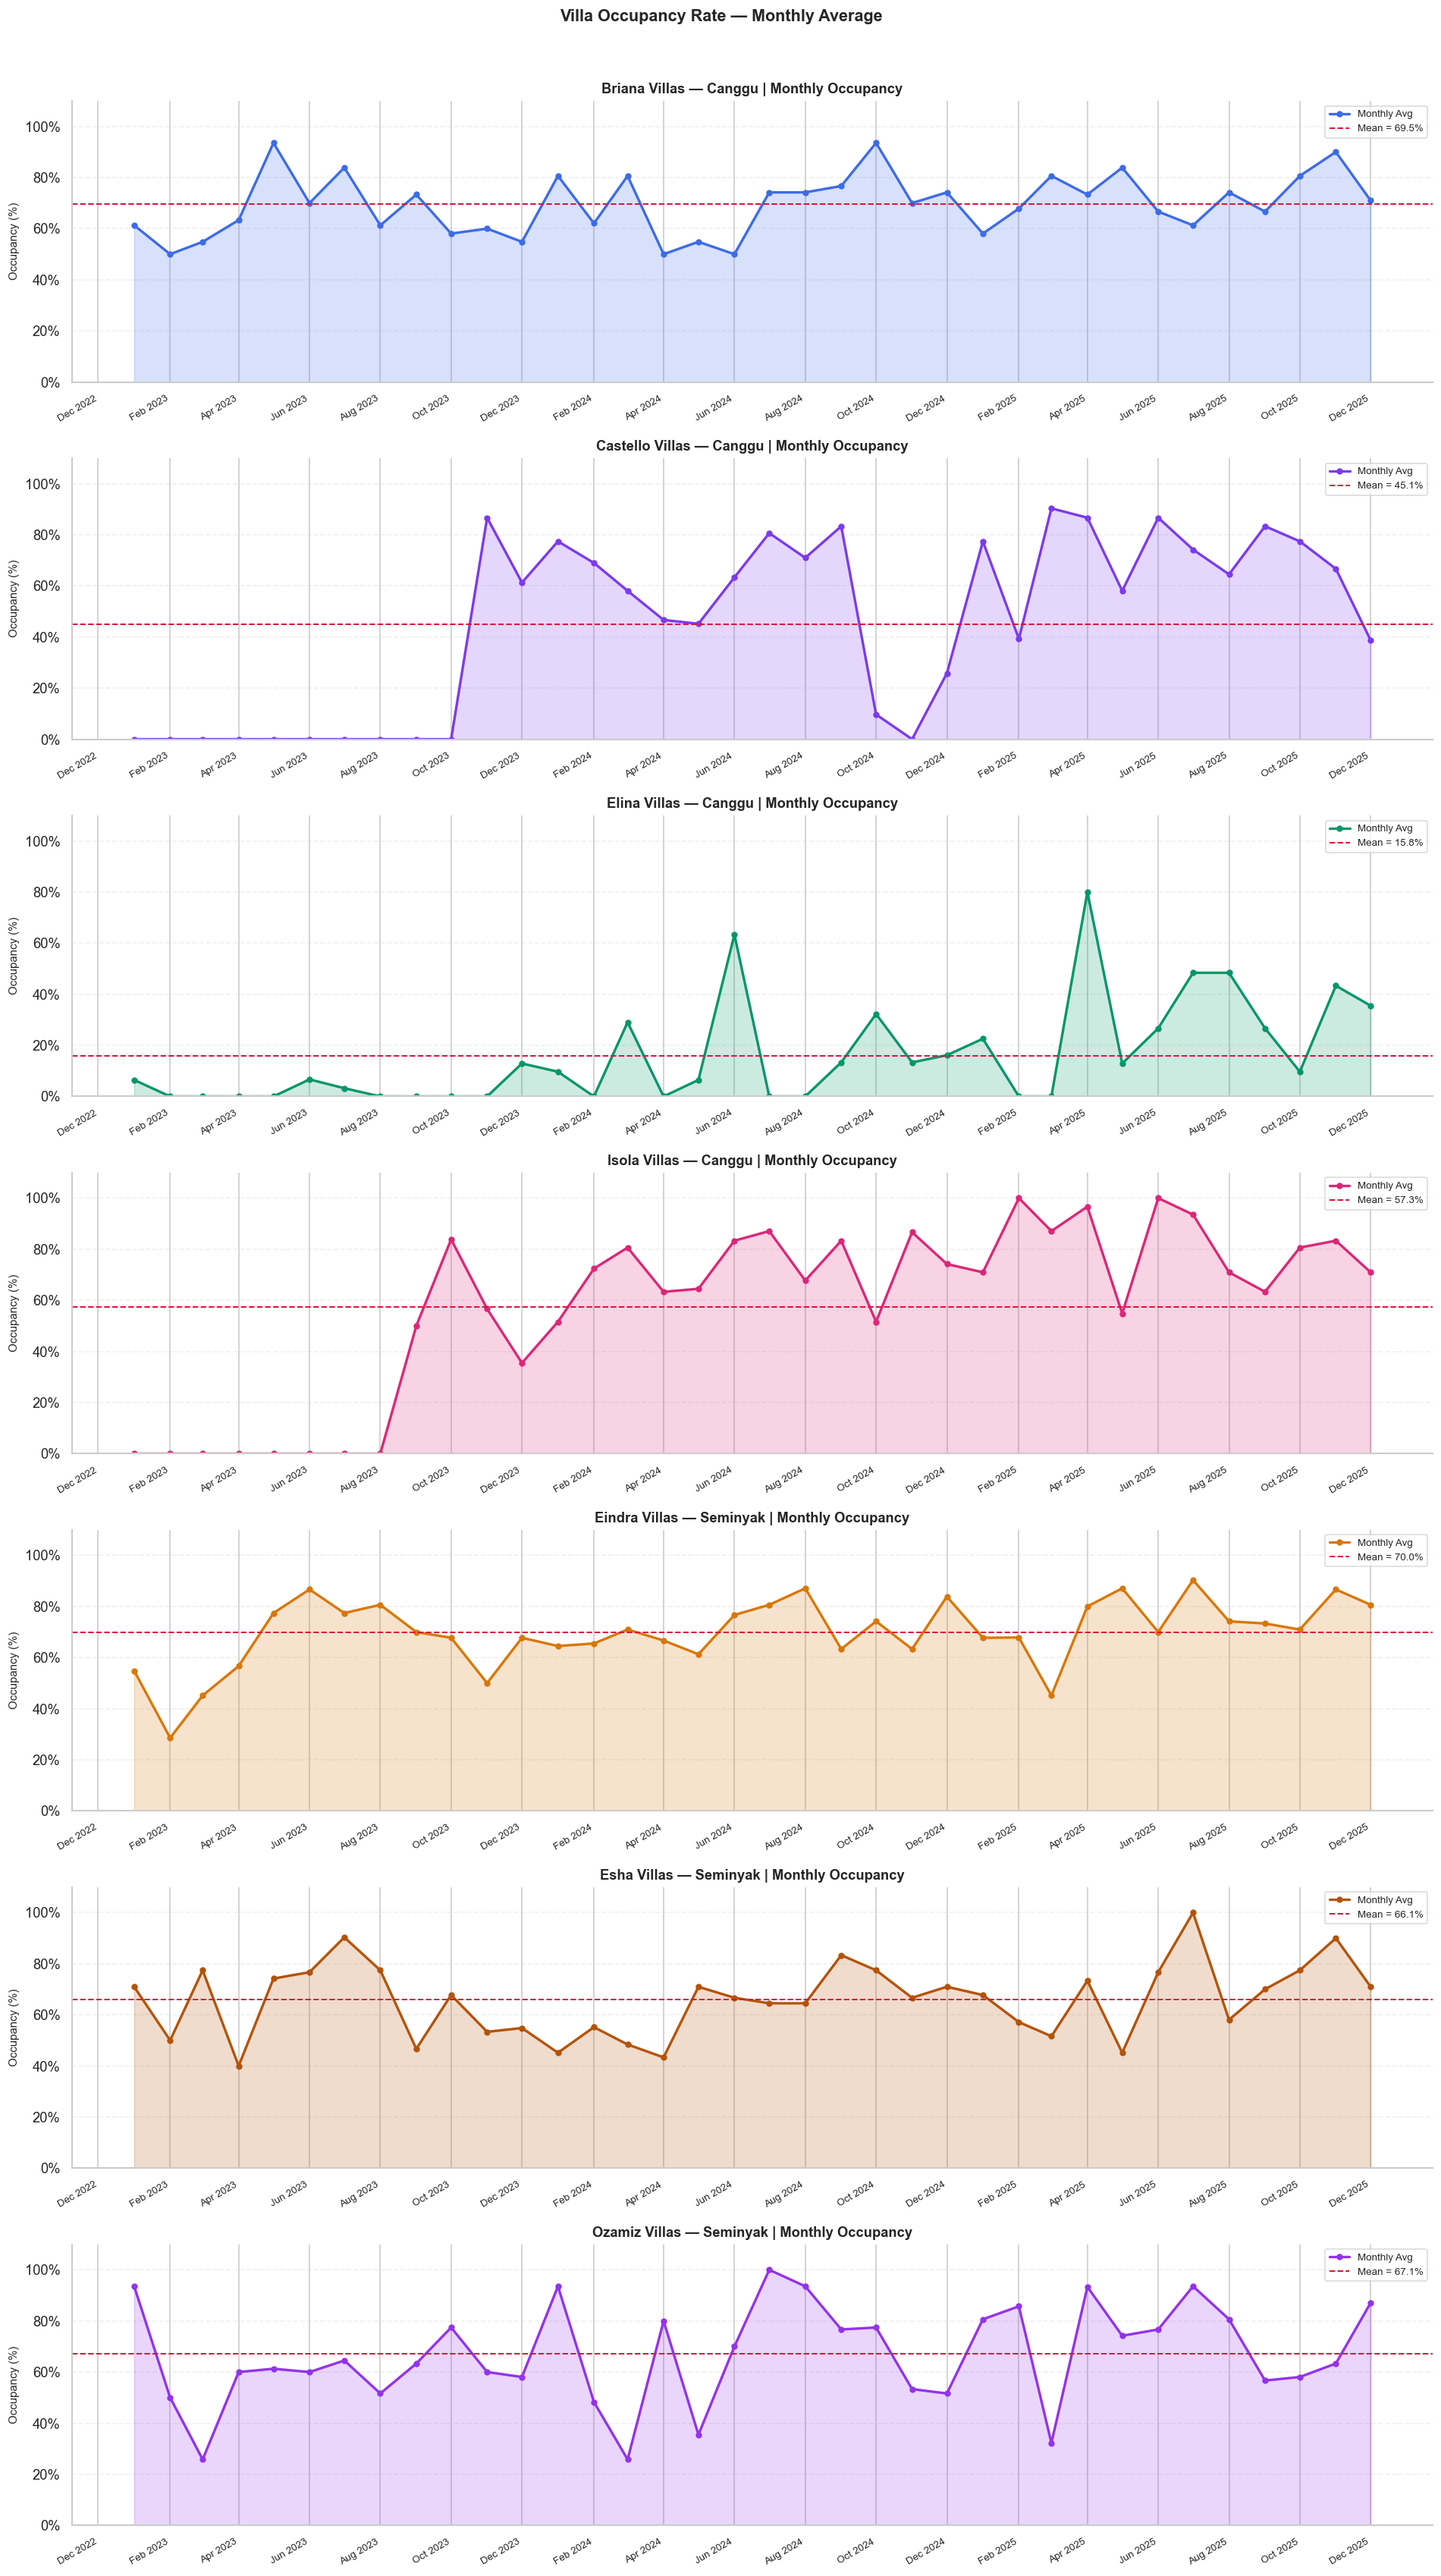

In [8]:
fig, axes = plt.subplots(len(clean_occ), 1, figsize=(16, 4 * len(clean_occ)))
if len(clean_occ) == 1:
    axes = [axes]

for idx, (villa, series) in enumerate(clean_occ.items()):
    ax       = axes[idx]
    config   = VILLA_CONFIG[villa]
    monthly  = series.resample('MS').mean()
    mean_val = series.mean()

    ax.fill_between(monthly.index, 0, monthly.values, alpha=0.20, color=config['color'])
    ax.plot(monthly.index, monthly.values, lw=2, color=config['color'],
            marker='o', markersize=4, label='Monthly Avg')
    ax.axhline(mean_val, color='crimson', ls='--', lw=1.2,
               label=f'Mean = {mean_val:.1f}%')
    ax.set_title(f"{villa.replace('_',' ').title()} — {config['area'].title()} | Monthly Occupancy",
                 fontweight='bold', fontsize=11, pad=6)
    ax.set_ylabel('Occupancy (%)', fontsize=9)
    ax.set_ylim(0, 110)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3, ls='--')
    ax.spines[['top','right']].set_visible(False)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.7)

plt.suptitle('Villa Occupancy Rate — Monthly Average', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_occupancy_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Statistik Deskriptif

In [9]:
stats_data = []
for villa, series in clean_occ.items():
    config = VILLA_CONFIG[villa]
    monthly = series.resample('MS').mean()
    stats_data.append({
        'Villa'     : villa.replace('_villas','').title(),
        'Area'      : config['area'].title(),
        'N (hari)'  : len(series),
        'N (bulan)' : len(monthly),
        'Mean (%)'  : round(series.mean(), 2),
        'Std (%)'   : round(series.std(), 2),
        'Min (%)'   : round(series.min(), 2),
        'Max (%)'   : round(series.max(), 2),
        'Median (%)': round(series.median(), 2),
        'Start'     : series.index.min().strftime('%Y-%m-%d'),
        'End'       : series.index.max().strftime('%Y-%m-%d'),
    })

stats_df = pd.DataFrame(stats_data)
print('STATISTIK DESKRIPTIF OCCUPANCY (0-100%)')
print('=' * 90)
display(stats_df)

STATISTIK DESKRIPTIF OCCUPANCY (0-100%)


,Villa,Area,N (hari),N (bulan),Mean (%),Std (%),Min (%),Max (%),Median (%),Start,End
0,Briana,Canggu,1096,36,69.53,46.05,0,100,100.00,2023-01-01,2025-12-31
1,Castello,Canggu,1096,36,45.07,49.78,0,100,0.00,2023-01-01,2025-12-31
2,Elina,Canggu,1096,36,15.78,36.48,0,100,0.00,2023-01-01,2025-12-31
3,Isola,Canggu,1096,36,57.30,49.49,0,100,100.00,2023-01-01,2025-12-31
4,Eindra,Seminyak,1096,36,69.98,45.85,0,100,100.00,2023-01-01,2025-12-31
5,Esha,Seminyak,1096,36,66.06,47.37,0,100,100.00,2023-01-01,2025-12-31
6,Ozamiz,Seminyak,1096,36,67.06,47.02,0,100,100.00,2023-01-01,2025-12-31


## 6. Uji Stasioneritas — ADF Test

UJI STASIONERITAS — AUGMENTED DICKEY-FULLER (alpha = 5%)


   Villa     Area  N (bln)  ADF (level)  p (level) p (diff1)  d dipakai                                           Keterangan
  Briana   Canggu       36        -1.62       0.47      0.00          1                         Diff(1) -> stasioner (p=0.0)
Castello   Canggu       36        -2.66       0.08      0.00          1                         Diff(1) -> stasioner (p=0.0)
   Elina   Canggu       36        -1.22       0.67      0.02          1                      Diff(1) -> stasioner (p=0.0247)
   Isola   Canggu       36        -2.35       0.16      0.16          1 Diff(1) belum sempurna (p=0.1613), d=1 tetap dipakai
  Eindra Seminyak       36        -3.77       0.00         -          0                                      Stasioner (d=0)
    Esha Seminyak       36        -5.02       0.00         -          0                                      Stasioner (d=0)
  Ozamiz Seminyak       36        -5.67       0.00         -          0                                      Stasioner (d=0)


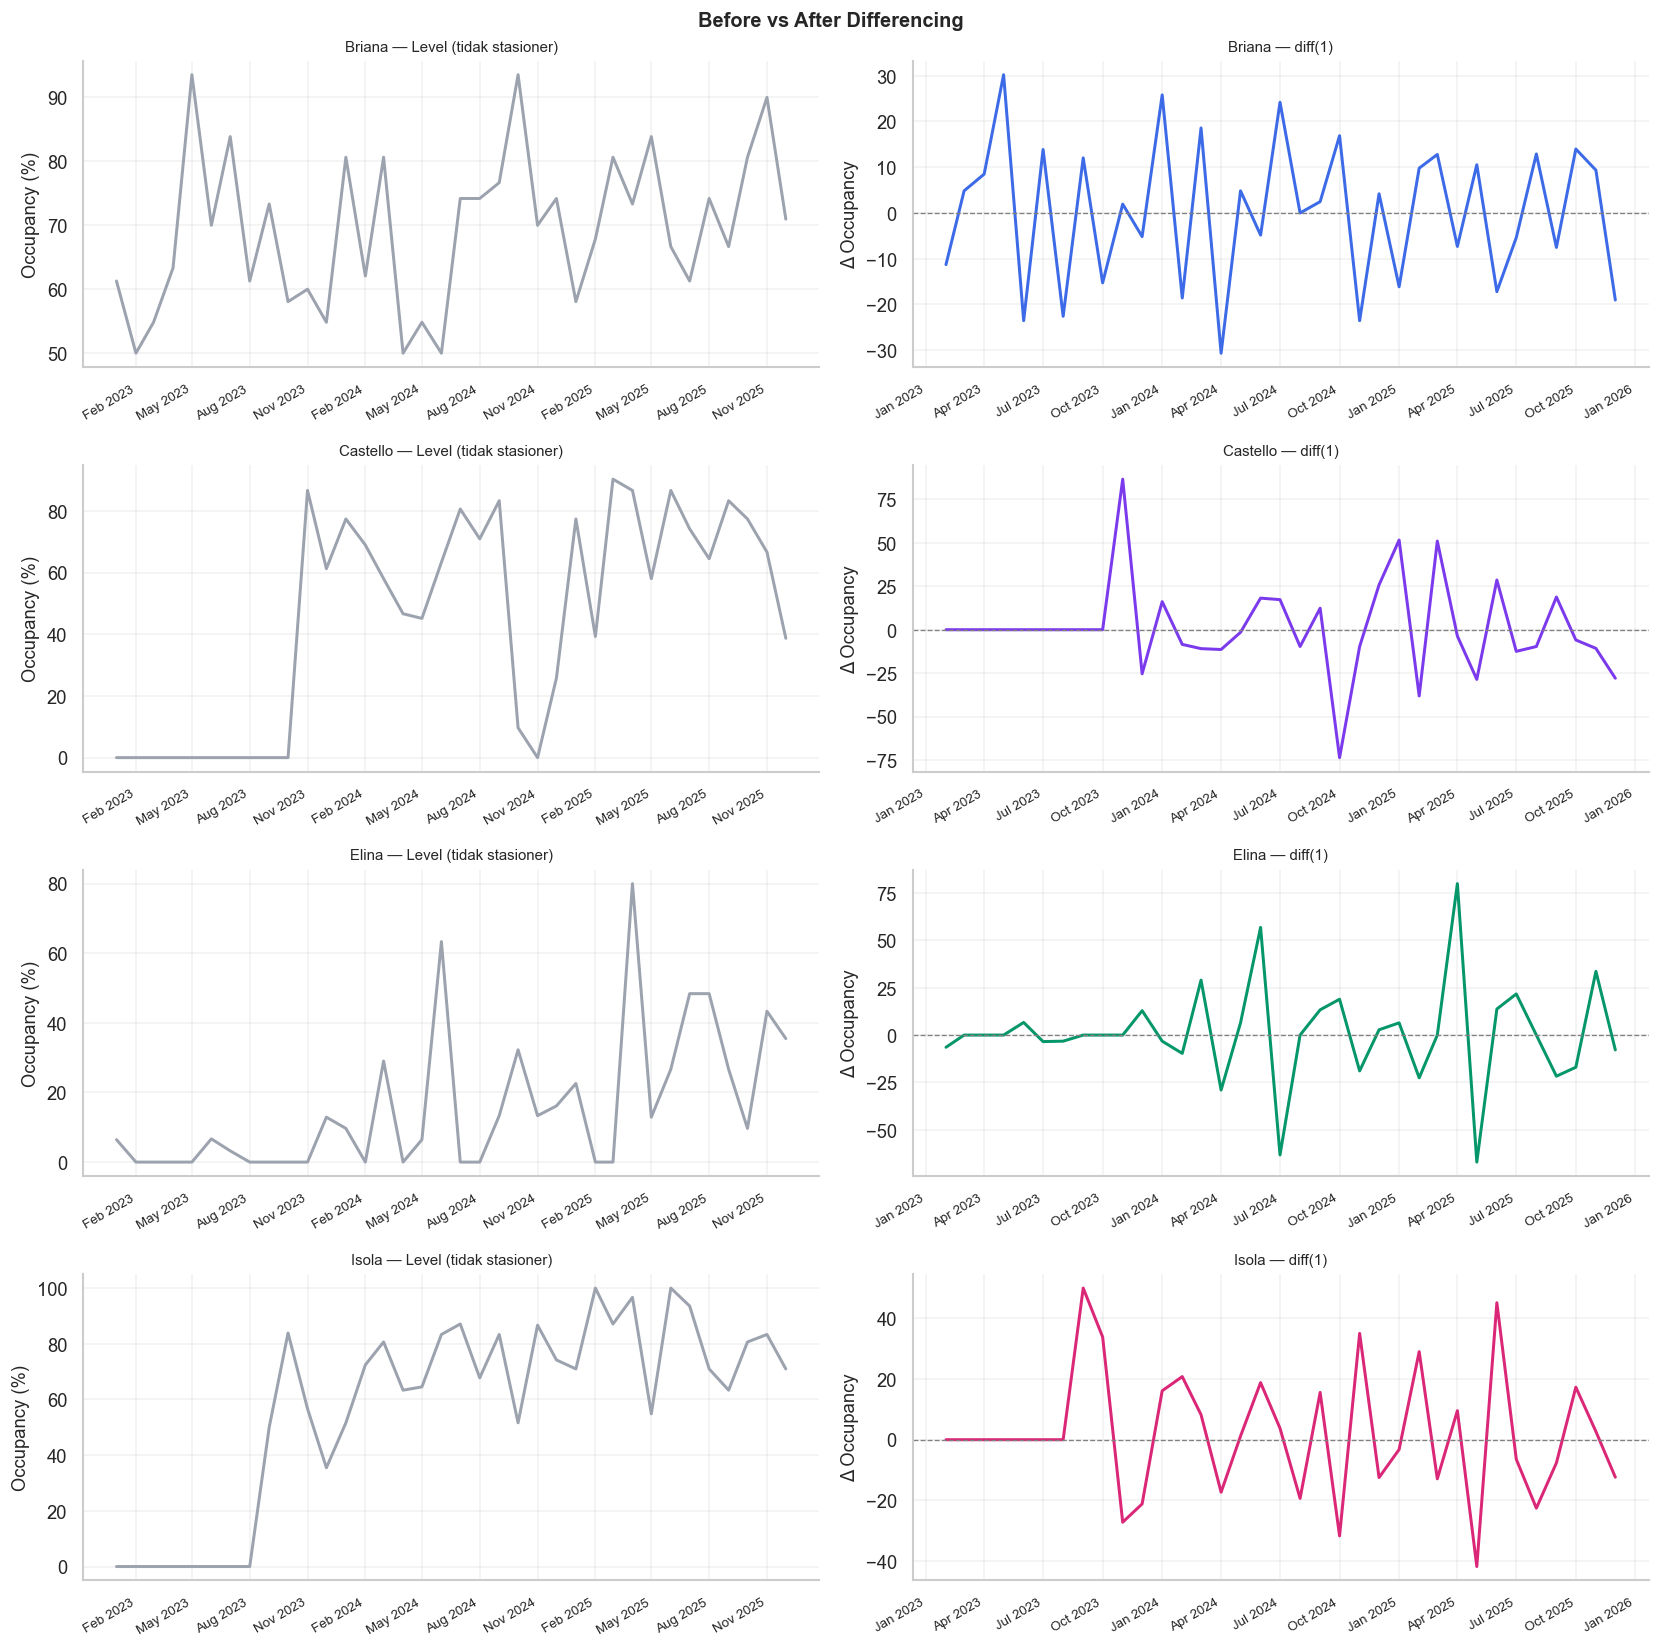

Uji ADF selesai.


In [10]:
def adf_check(series, alpha=0.05):
    res = adfuller(series.dropna(), autolag='AIC')
    return res[1] < alpha, round(res[1], 4), round(res[0], 4)

clean_occ_stationary = {}
villa_d              = {}
adf_results          = []

print('UJI STASIONERITAS — AUGMENTED DICKEY-FULLER (alpha = 5%)')
print('=' * 90)

for villa, series in clean_occ.items():
    monthly = series.resample('MS').mean().dropna()
    title   = villa.replace('_villas', '').title()
    area    = VILLA_CONFIG[villa]['area'].title()

    stat0, p0, adf0 = adf_check(monthly)

    if stat0:
        d_used       = 0
        series_final = monthly
        p1           = '-'
        note         = 'Stasioner (d=0)'
    else:
        diff1        = monthly.diff().dropna()
        stat1, p1, _ = adf_check(diff1)
        d_used       = 1   # dibatasi maksimum d=1, tidak lanjut ke d=2
        series_final = diff1
        note = (f'Diff(1) -> stasioner (p={p1})' if stat1
                else f'Diff(1) belum sempurna (p={p1}), d=1 tetap dipakai')

    # d dipaksa tidak lebih dari 1
    d_used = min(d_used, 1)

    clean_occ_stationary[villa] = series_final
    villa_d[villa]              = d_used

    adf_results.append({
        'Villa'       : title,
        'Area'        : area,
        'N (bln)'     : len(monthly),
        'ADF (level)' : adf0,
        'p (level)'   : p0,
        'p (diff1)'   : p1,
        'd dipakai'   : d_used,
        'Keterangan'  : note,
    })

adf_df = pd.DataFrame(adf_results)
print(adf_df[['Villa','Area','N (bln)','ADF (level)','p (level)','p (diff1)',
               'd dipakai','Keterangan']].to_string(index=False))
print(f'\nvilla_d = {villa_d}')

# Plot before/after untuk villa yang di-differencing
villa_diffed = [v for v, d in villa_d.items() if d > 0]
if villa_diffed:
    fig, axes = plt.subplots(len(villa_diffed), 2,
                             figsize=(14, 3.5 * len(villa_diffed)))
    if len(villa_diffed) == 1:
        axes = [axes]
    for ax_row, villa in zip(axes, villa_diffed):
        color   = VILLA_CONFIG[villa]['color']
        title   = villa.replace('_villas','').title()
        monthly = clean_occ[villa].resample('MS').mean().dropna()
        stat_s  = clean_occ_stationary[villa]
        ax_row[0].plot(monthly.index, monthly.values, color='#9ca3af', lw=1.8)
        ax_row[0].set_title(f'{title} — Level (tidak stasioner)', fontsize=9)
        ax_row[0].set_ylabel('Occupancy (%)')
        ax_row[1].plot(stat_s.index, stat_s.values, color=color, lw=1.8)
        ax_row[1].axhline(0, color='gray', ls='--', lw=0.8)
        ax_row[1].set_title(f'{title} — diff(1)', fontsize=9)
        ax_row[1].set_ylabel('Δ Occupancy')
        for ax in ax_row:
            ax.grid(alpha=0.25); ax.spines[['top','right']].set_visible(False)
            ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
    plt.suptitle('Before vs After Differencing', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('adf_before_after.png', dpi=150, bbox_inches='tight')
    plt.show()
print('Uji ADF selesai.')

## 7. Seasonal Decomposition

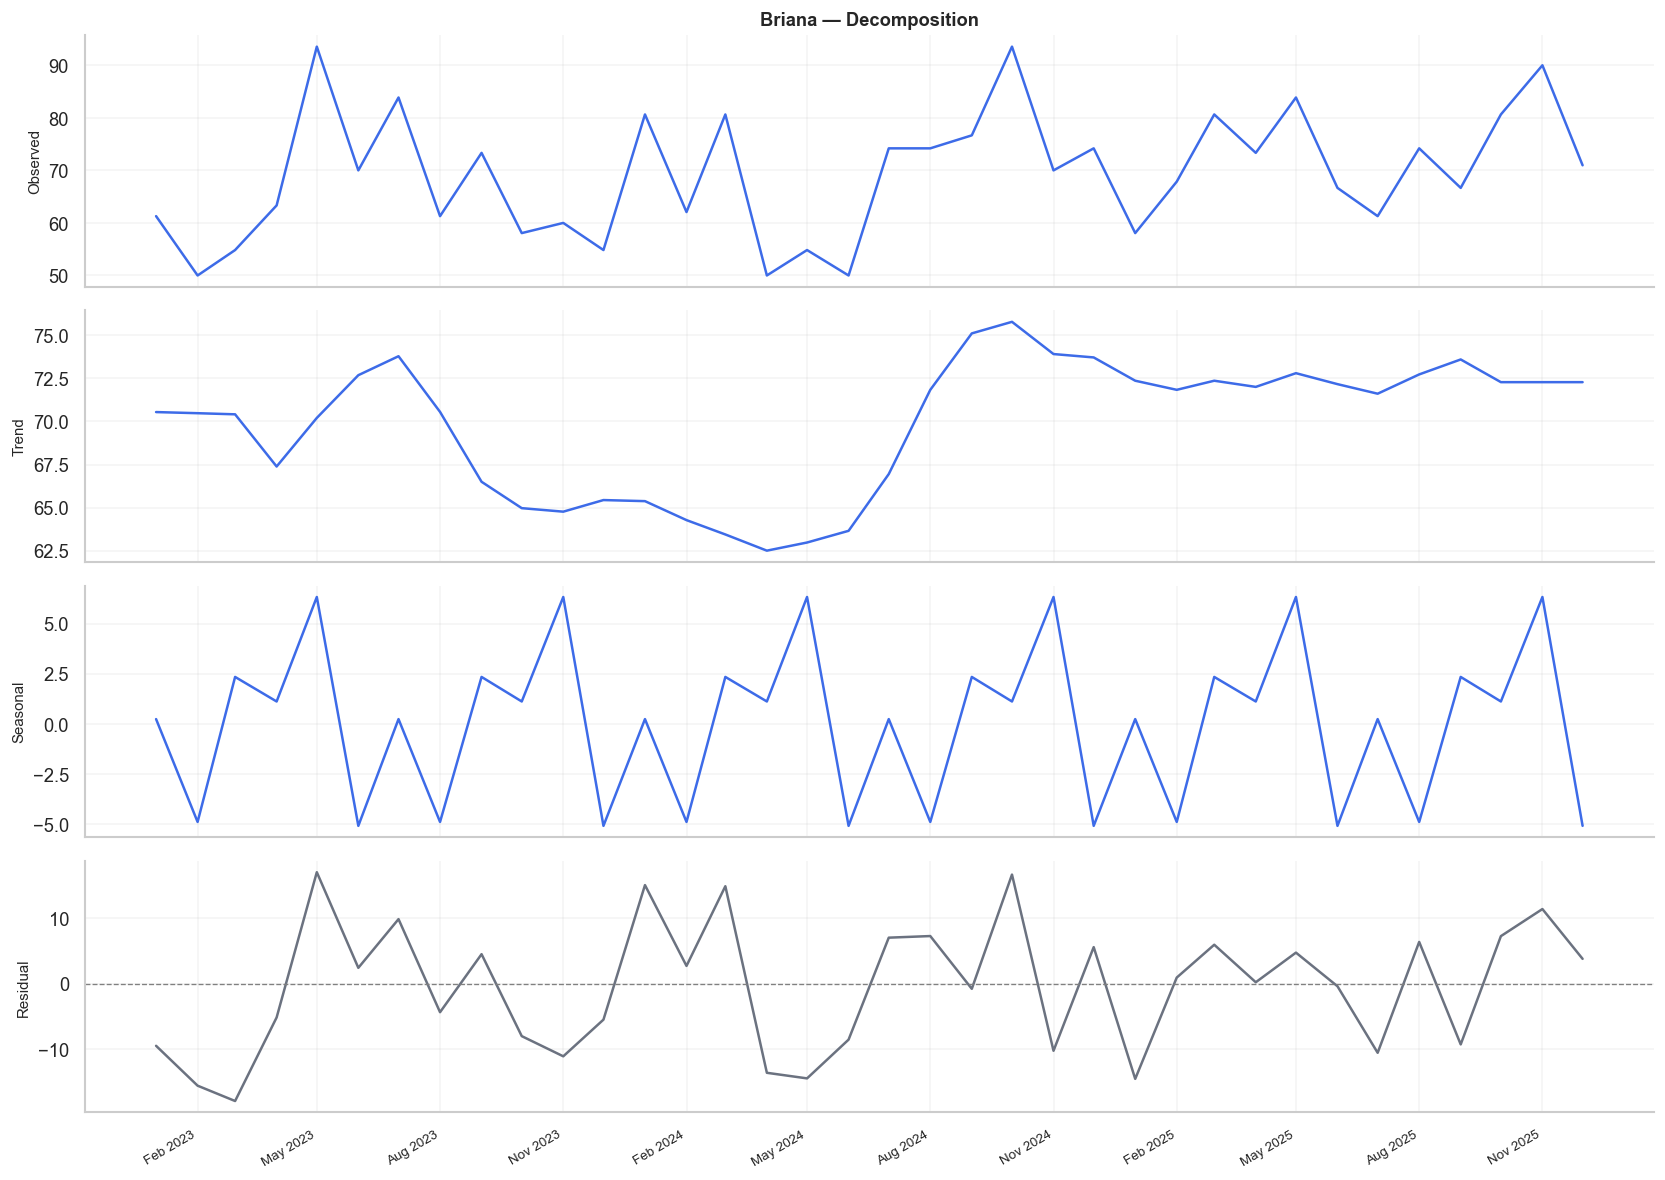

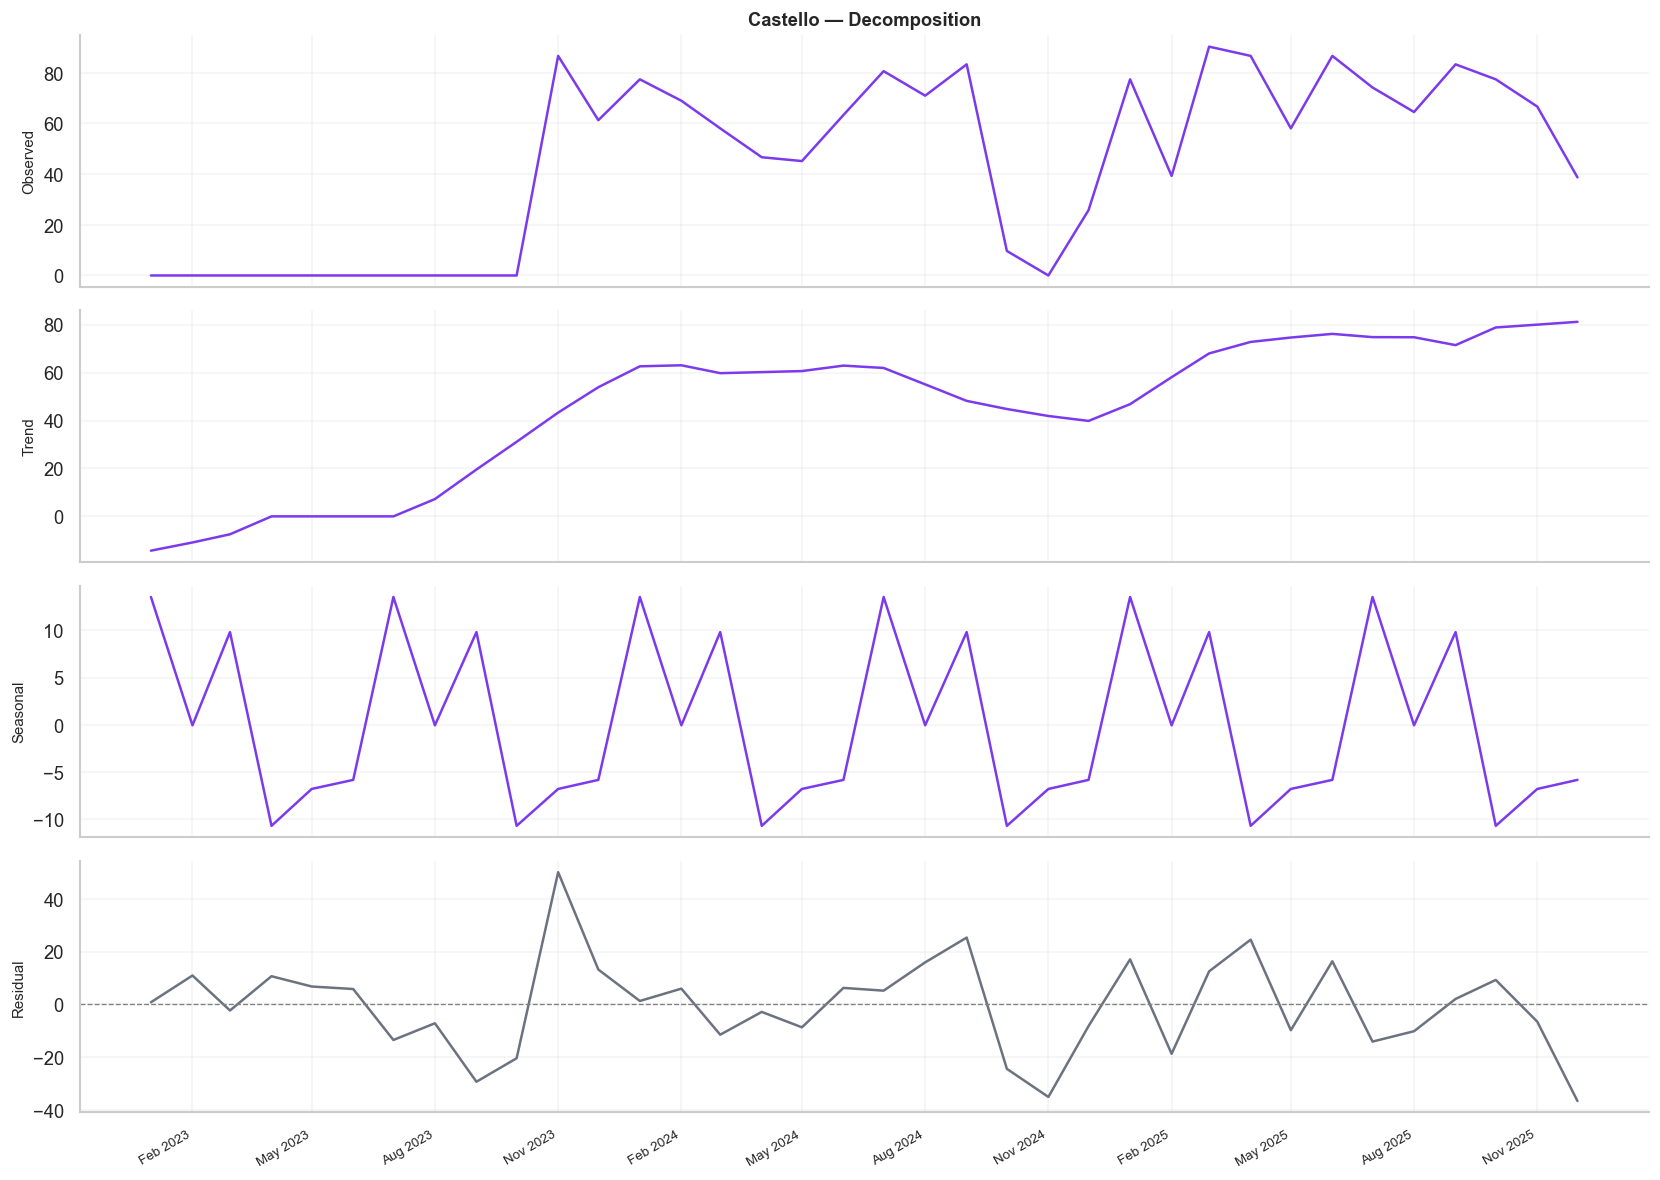

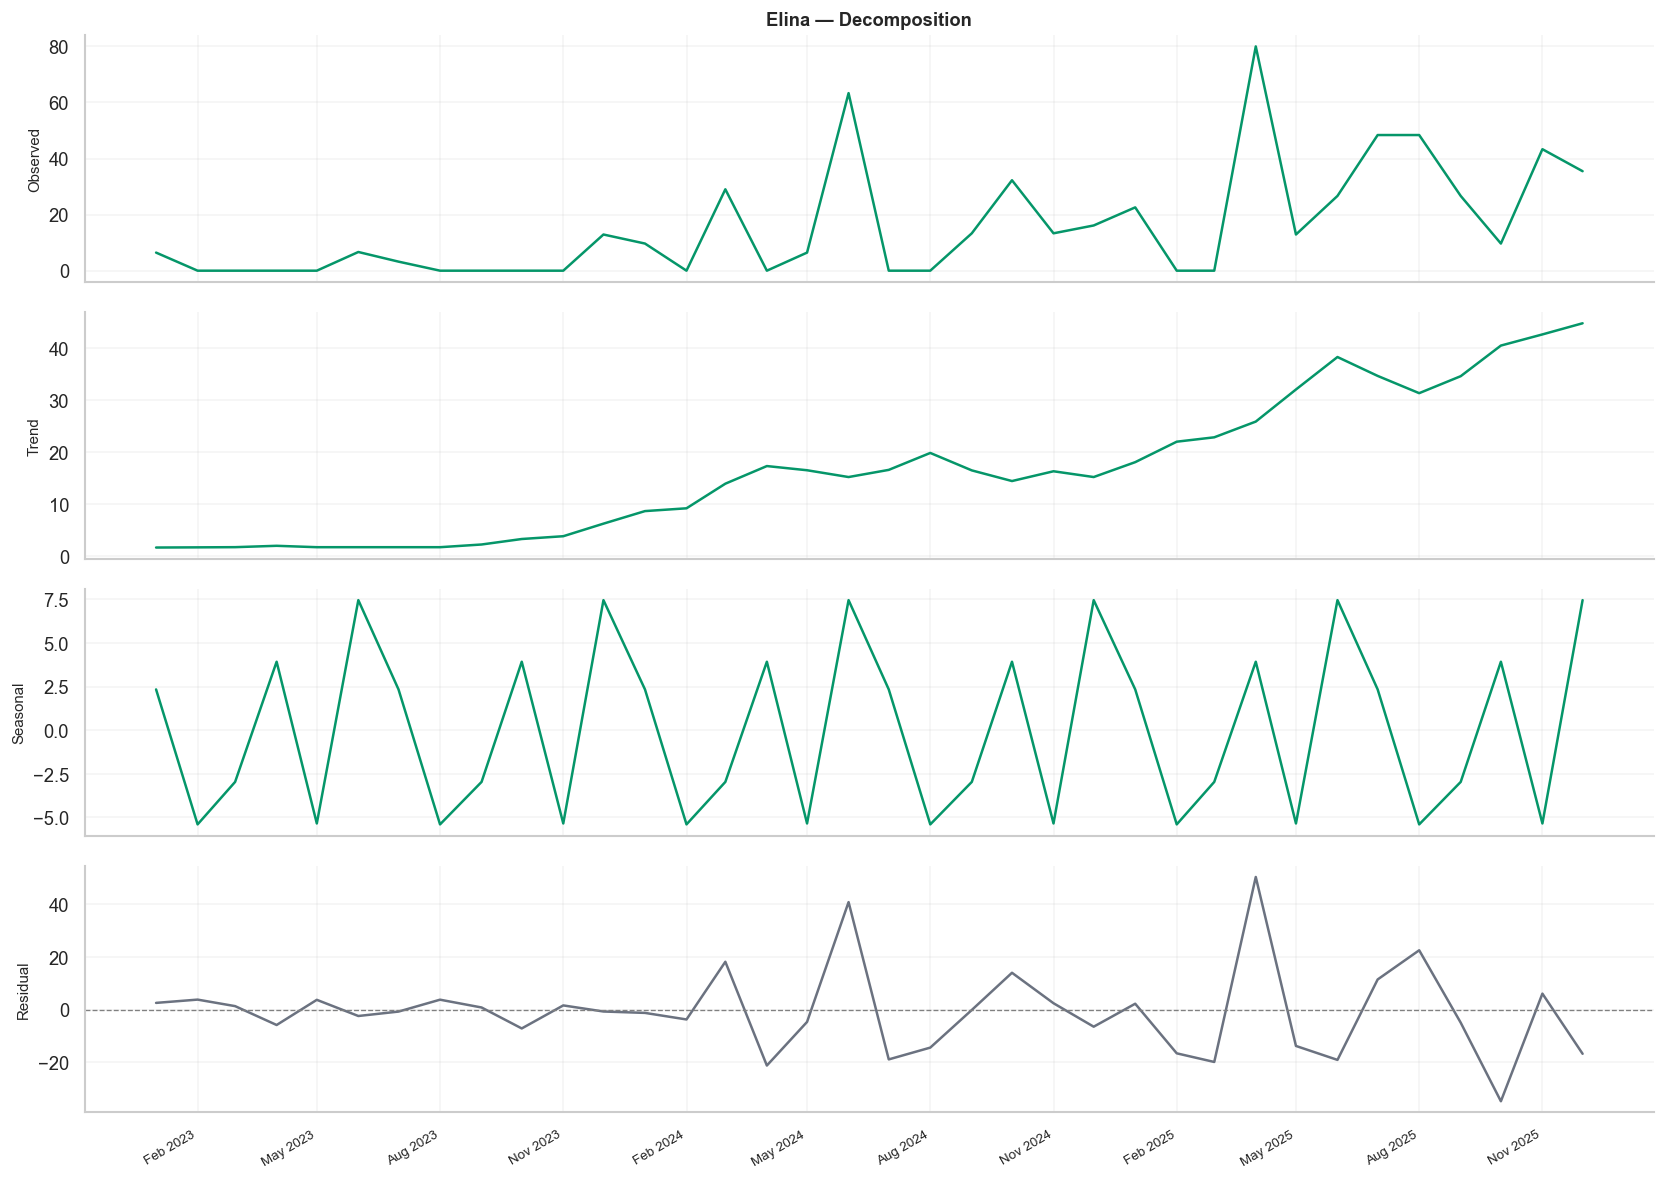

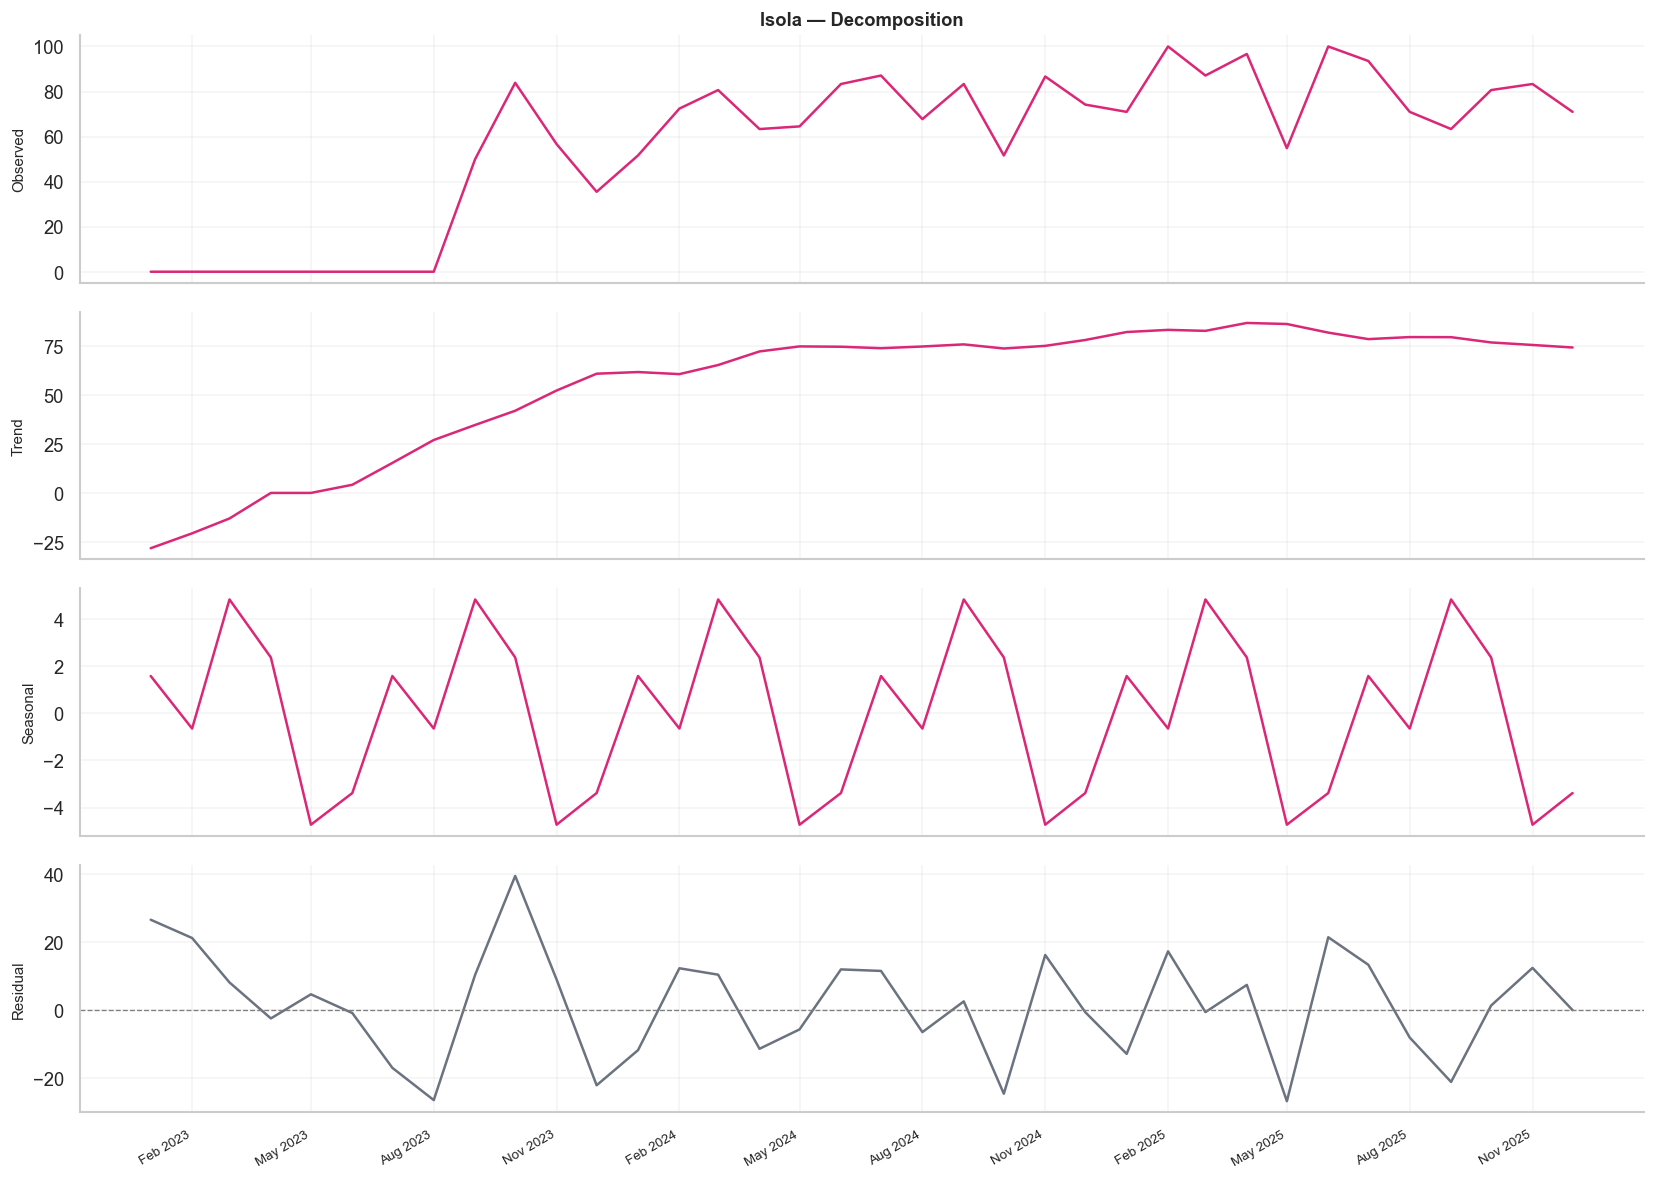

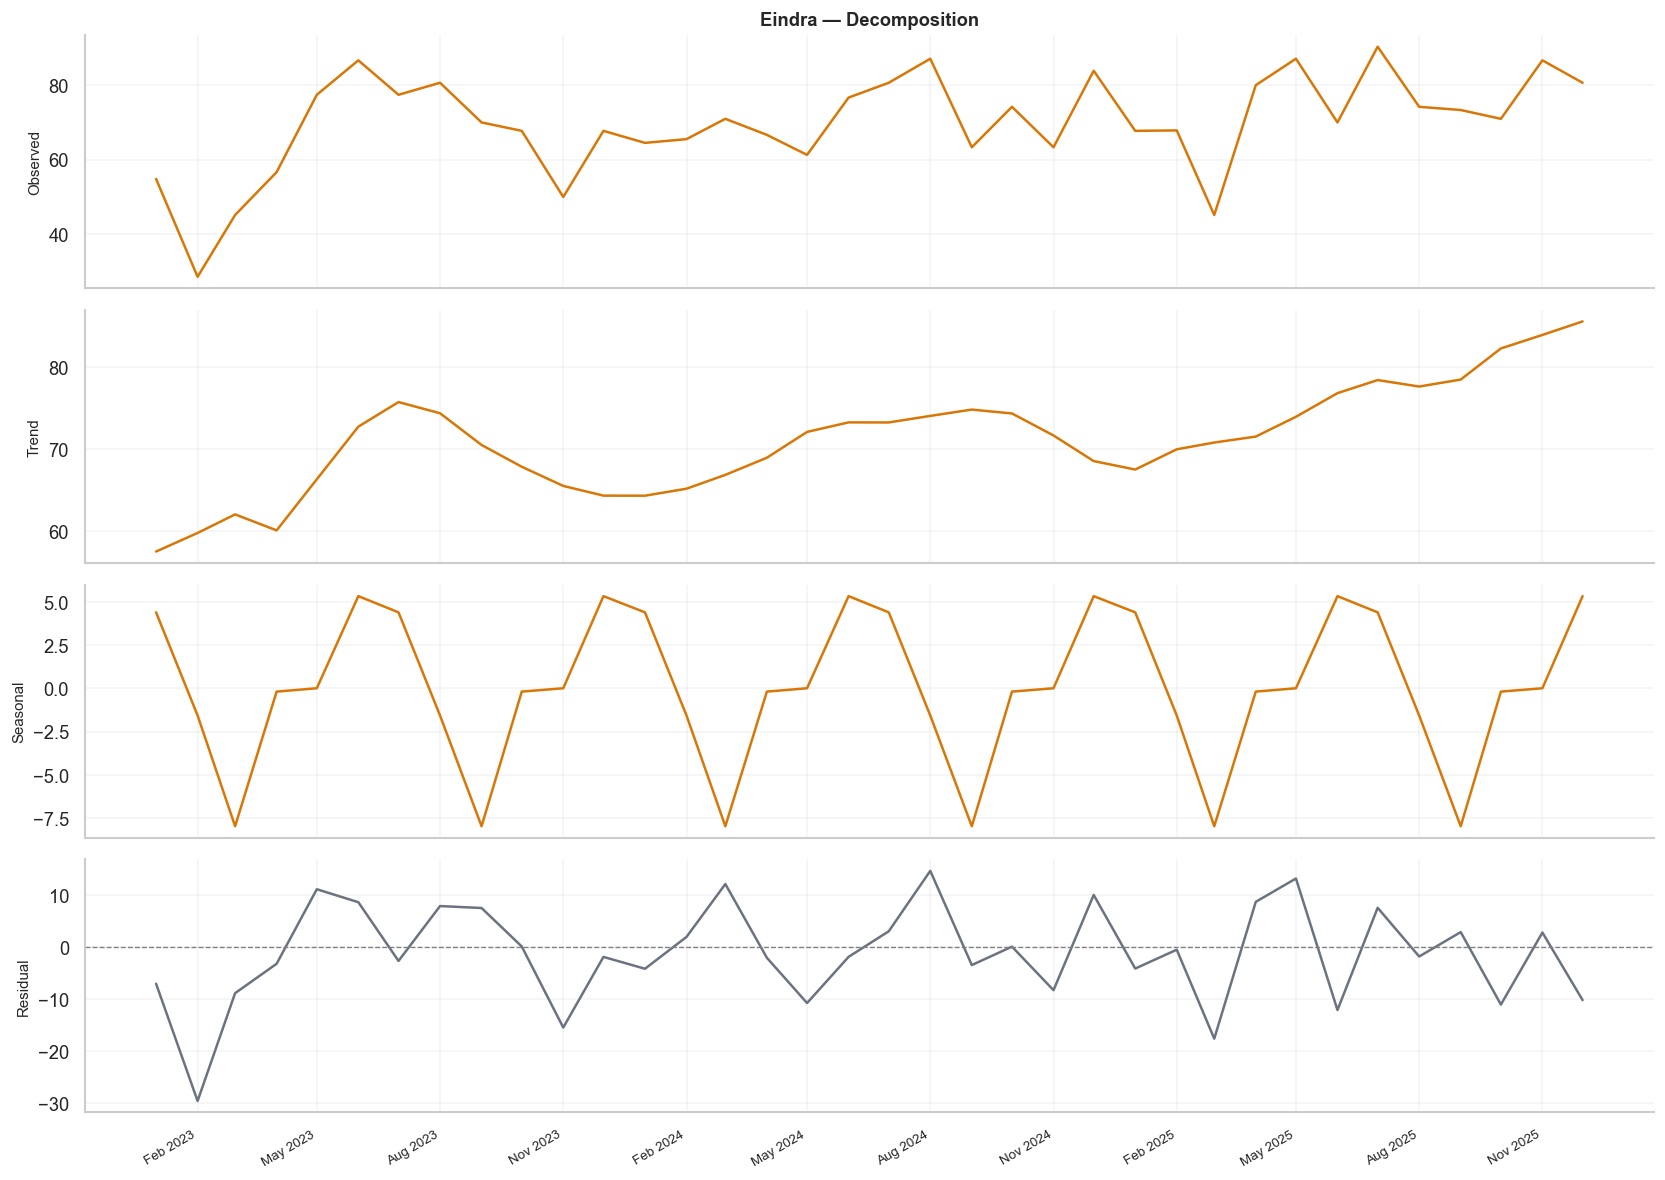

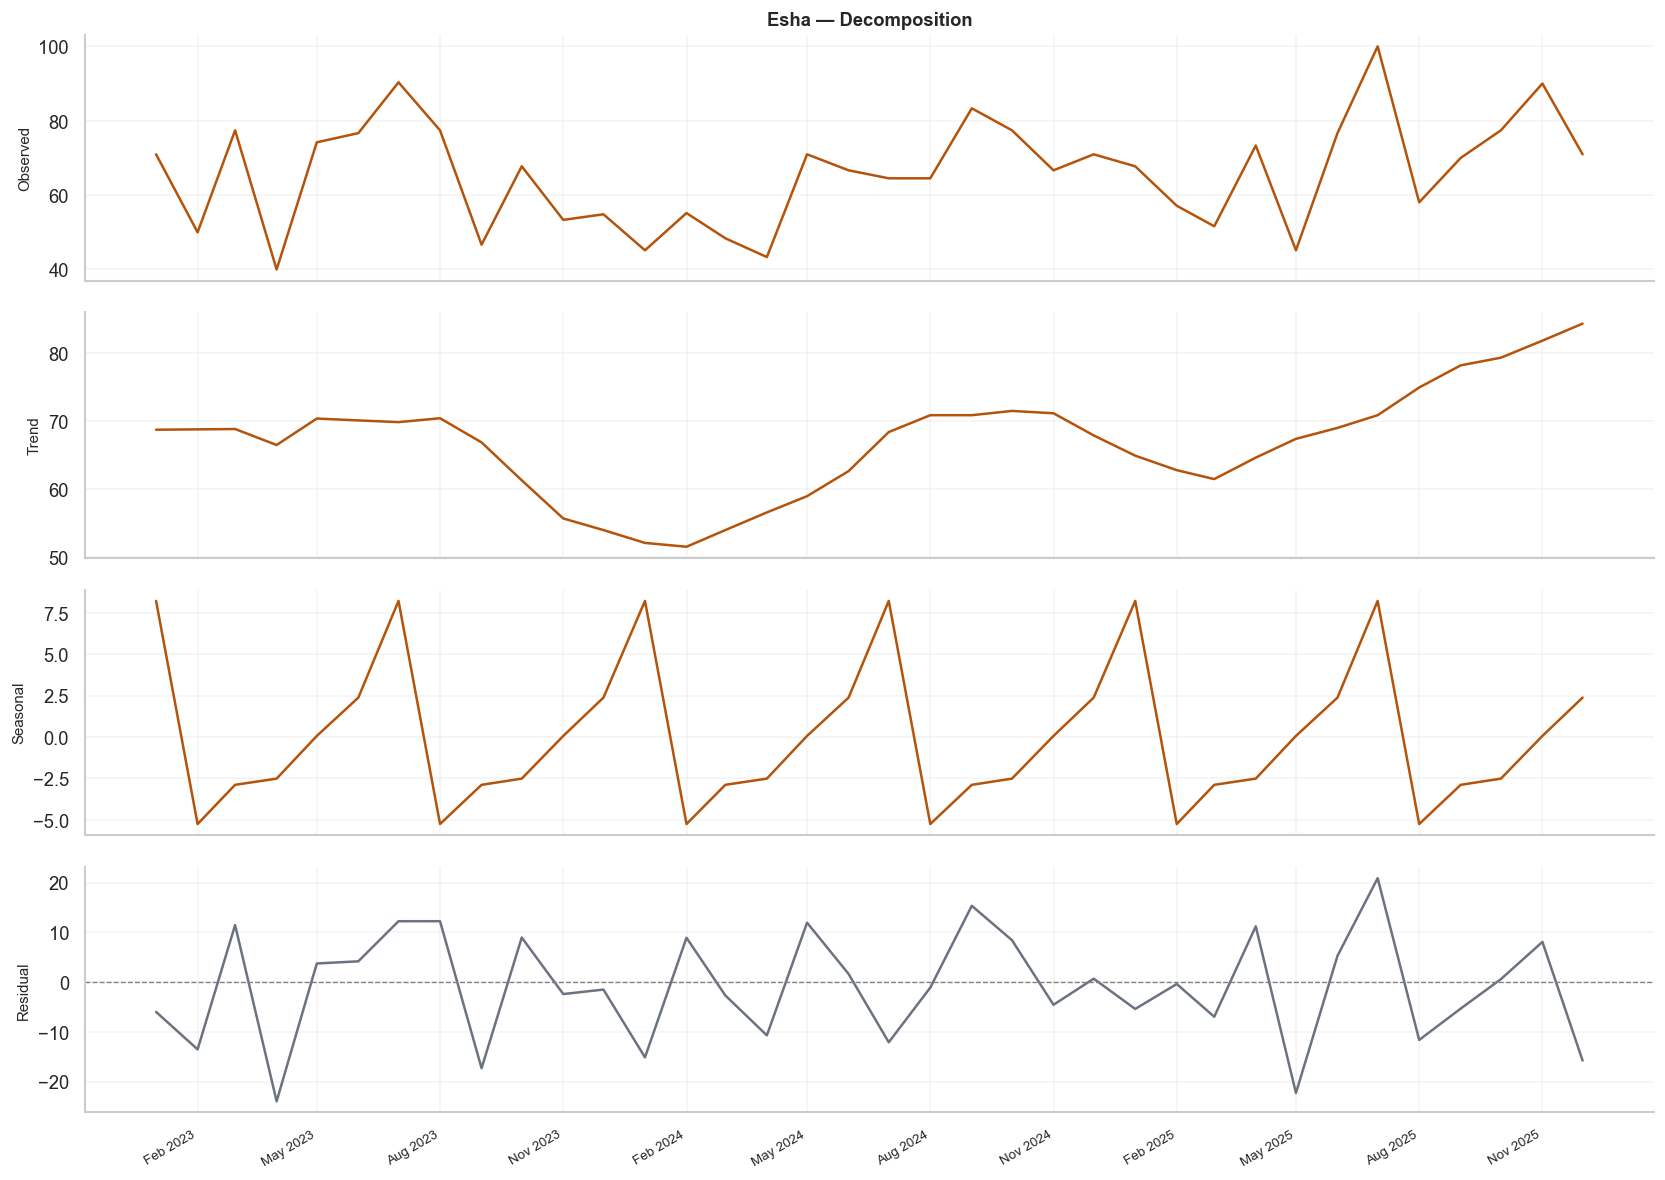

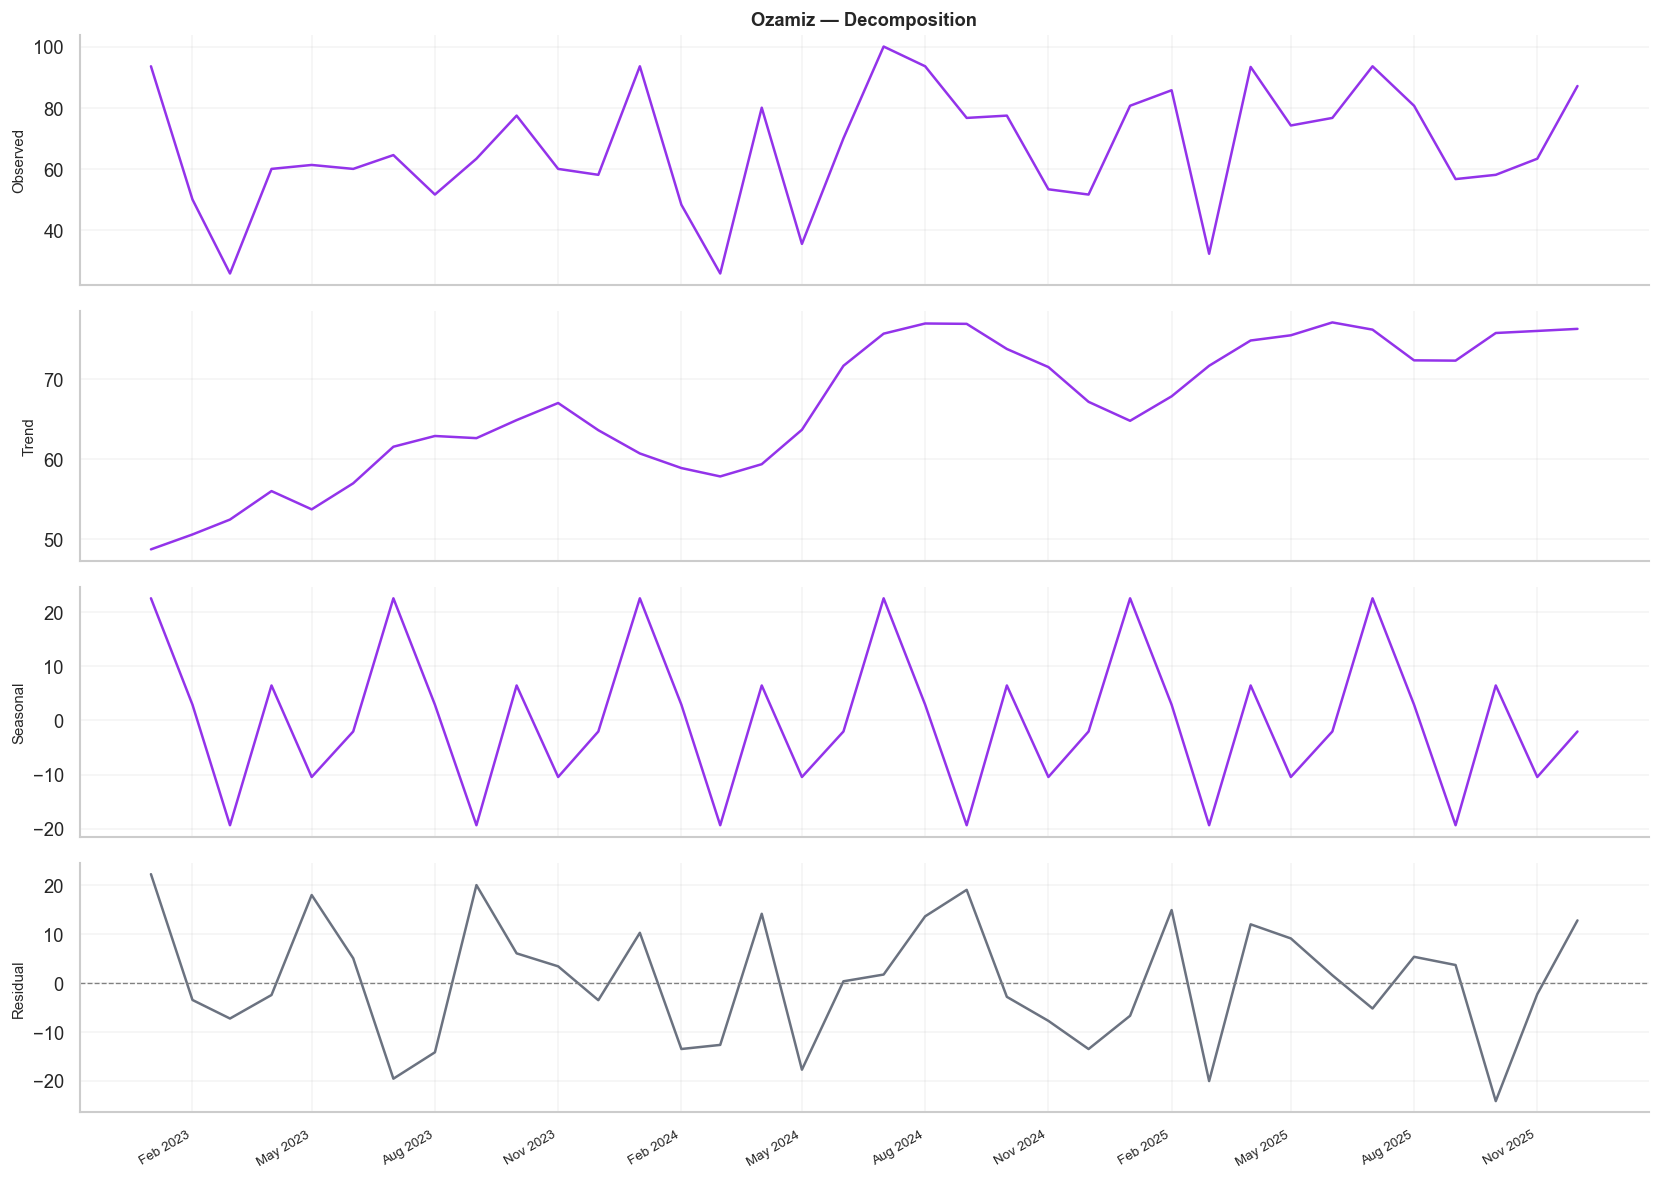

Seasonal decomposition selesai.


In [11]:
for villa, series in clean_occ.items():
    monthly  = series.resample('MS').mean().dropna()
    if len(monthly) < 24:
        print(f'[{villa}] < 24 bulan -> skip.')
        continue
    m_villa = villa_m.get(villa, 6) if 'villa_m' in dir() else 6
    decomp  = seasonal_decompose(monthly, model='additive', period=m_villa,
                                 extrapolate_trend='freq')
    color   = VILLA_CONFIG[villa]['color']
    title   = villa.replace('_villas','').title()

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    for ax, (comp, label) in zip(axes, [
        (decomp.observed,'Observed'),(decomp.trend,'Trend'),
        (decomp.seasonal,'Seasonal'),(decomp.resid,'Residual')
    ]):
        ax.plot(monthly.index, comp,
                color=color if label != 'Residual' else '#6b7280', lw=1.5)
        if label == 'Residual':
            ax.axhline(0, color='gray', ls='--', lw=0.8)
        ax.set_ylabel(label, fontsize=9)
        ax.grid(alpha=0.2); ax.spines[['top','right']].set_visible(False)
    axes[0].set_title(f'{title} — Decomposition',
                      fontweight='bold', fontsize=11)
    axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'decomp_{villa}.png', dpi=150, bbox_inches='tight')
    plt.show()
print('Seasonal decomposition selesai.')

## 7b. Deteksi Periode Dominan (m) — Periodogram + ACF

In [12]:
MIN_CYCLES = 2
ACF_ALPHA  = 0.10
FALLBACK_M = 6

def detect_m(monthly, villa_label, min_cycles=MIN_CYCLES, fallback=FALLBACK_M):
    n     = len(monthly)
    MAX_M = max(n // 4, 4)

    freqs, power = scipy_periodogram(monthly.values)
    valid_mask   = freqs[1:] > 0
    periods_raw  = 1.0 / freqs[1:][valid_mask]
    power_raw    = power[1:][valid_mask]

    periods_int  = np.round(periods_raw).astype(int)
    period_power = {}
    for p, pw in zip(periods_int, power_raw):
        if p not in period_power or pw > period_power[p]:
            period_power[p] = pw

    sorted_periods = sorted(period_power, key=period_power.get, reverse=True)
    top5 = sorted_periods[:5]

    pgram_m = None
    for p in sorted_periods:
        if 4 <= p <= MAX_M:
            pgram_m = int(p)
            break

    nlags = min(n // 2, 24)
    try:
        acf_vals, ci = sm_acf(monthly, nlags=nlags, alpha=ACF_ALPHA, fft=True)
        acf_spike_m  = None
        for lag in range(4, nlags + 1):
            if 4 <= lag <= MAX_M:
                outside = (acf_vals[lag] > ci[lag][1] - acf_vals[lag] or
                           acf_vals[lag] < ci[lag][0] - acf_vals[lag])
                if outside:
                    acf_spike_m = lag
                    break
    except Exception:
        acf_spike_m = None

    if pgram_m is not None:
        m_final, method = pgram_m, 'periodogram'
    elif acf_spike_m is not None:
        m_final, method = acf_spike_m, 'acf_only'
    else:
        m_final, method = fallback, 'fallback'

    m_final = min(m_final, MAX_M)

    return m_final, method, {
        'pgram_m'     : pgram_m,
        'acf_spike'   : acf_spike_m,
        'n'           : n,
        'MAX_M'       : MAX_M,
        'top5_periods': top5
    }

# Jalankan deteksi m untuk semua villa (tanpa plot)
villa_m       = {}
m_det_results = []

print('DETEKSI PERIODE DOMINAN (m) — PERIODOGRAM + ACF  [NO PLOT MODE]')
print('Batas: MAX_M = n // 4')
print('=' * 70)

for villa, series in clean_occ.items():
    monthly = series.resample('MS').mean().dropna()
    title   = villa.replace('_villas','').title()
    area    = VILLA_CONFIG[villa]['area'].title()
    m_final, method, detail = detect_m(monthly, title)
    villa_m[villa] = m_final

    status = 'OK' if method != 'fallback' else 'fallback'
    print(f'  [{title:20s}]  n={detail["n"]:>3}  MAX_M={detail["MAX_M"]:>3}  '
          f'pgram={str(detail["pgram_m"]):>5}  acf={str(detail["acf_spike"]):>5}  '
          f'-> m={m_final}  ({method})  {status}')

    m_det_results.append({
        'Villa'       : title,
        'Area'        : area,
        'N (bln)'     : detail['n'],
        'MAX_M (n//4)': detail['MAX_M'],
        'm terpilih'  : m_final,
        'Metode'      : method,
        'Top-5 pgram' : str(detail['top5_periods']),
        'Status'      : 'OK' if method != 'fallback' else 'fallback',
    })

print('=' * 70)

m_df = pd.DataFrame(m_det_results)
display(m_df[['Villa', 'Area', 'N (bln)', 'MAX_M (n//4)', 'm terpilih', 'Metode', 'Status']])

print(f'\nvilla_m = {villa_m}')
print('\nDeteksi m selesai (no plot).')

DETEKSI PERIODE DOMINAN (m) — PERIODOGRAM + ACF  [NO PLOT MODE]
Batas: MAX_M = n // 4
  [Briana              ]  n= 36  MAX_M=  9  pgram=    7  acf= None  -> m=7  (periodogram)  OK
  [Castello            ]  n= 36  MAX_M=  9  pgram=    7  acf= None  -> m=7  (periodogram)  OK
  [Elina               ]  n= 36  MAX_M=  9  pgram=    4  acf= None  -> m=4  (periodogram)  OK
  [Isola               ]  n= 36  MAX_M=  9  pgram=    5  acf=    4  -> m=5  (periodogram)  OK
  [Eindra              ]  n= 36  MAX_M=  9  pgram=    6  acf= None  -> m=6  (periodogram)  OK
  [Esha                ]  n= 36  MAX_M=  9  pgram=    4  acf=    8  -> m=4  (periodogram)  OK
  [Ozamiz              ]  n= 36  MAX_M=  9  pgram=    6  acf= None  -> m=6  (periodogram)  OK


,Villa,Area,N (bln),MAX_M (n//4),m terpilih,Metode,Status
0,Briana,Canggu,36,9,7,periodogram,OK
1,Castello,Canggu,36,9,7,periodogram,OK
2,Elina,Canggu,36,9,4,periodogram,OK
3,Isola,Canggu,36,9,5,periodogram,OK
4,Eindra,Seminyak,36,9,6,periodogram,OK
5,Esha,Seminyak,36,9,4,periodogram,OK
6,Ozamiz,Seminyak,36,9,6,periodogram,OK



villa_m = {'briana_villas': 7, 'castello_villas': 7, 'elina_villas': 4, 'isola_villas': 5, 'eindra_villas': 6, 'esha_villas': 4, 'ozamiz_villas': 6}

Deteksi m selesai (no plot).


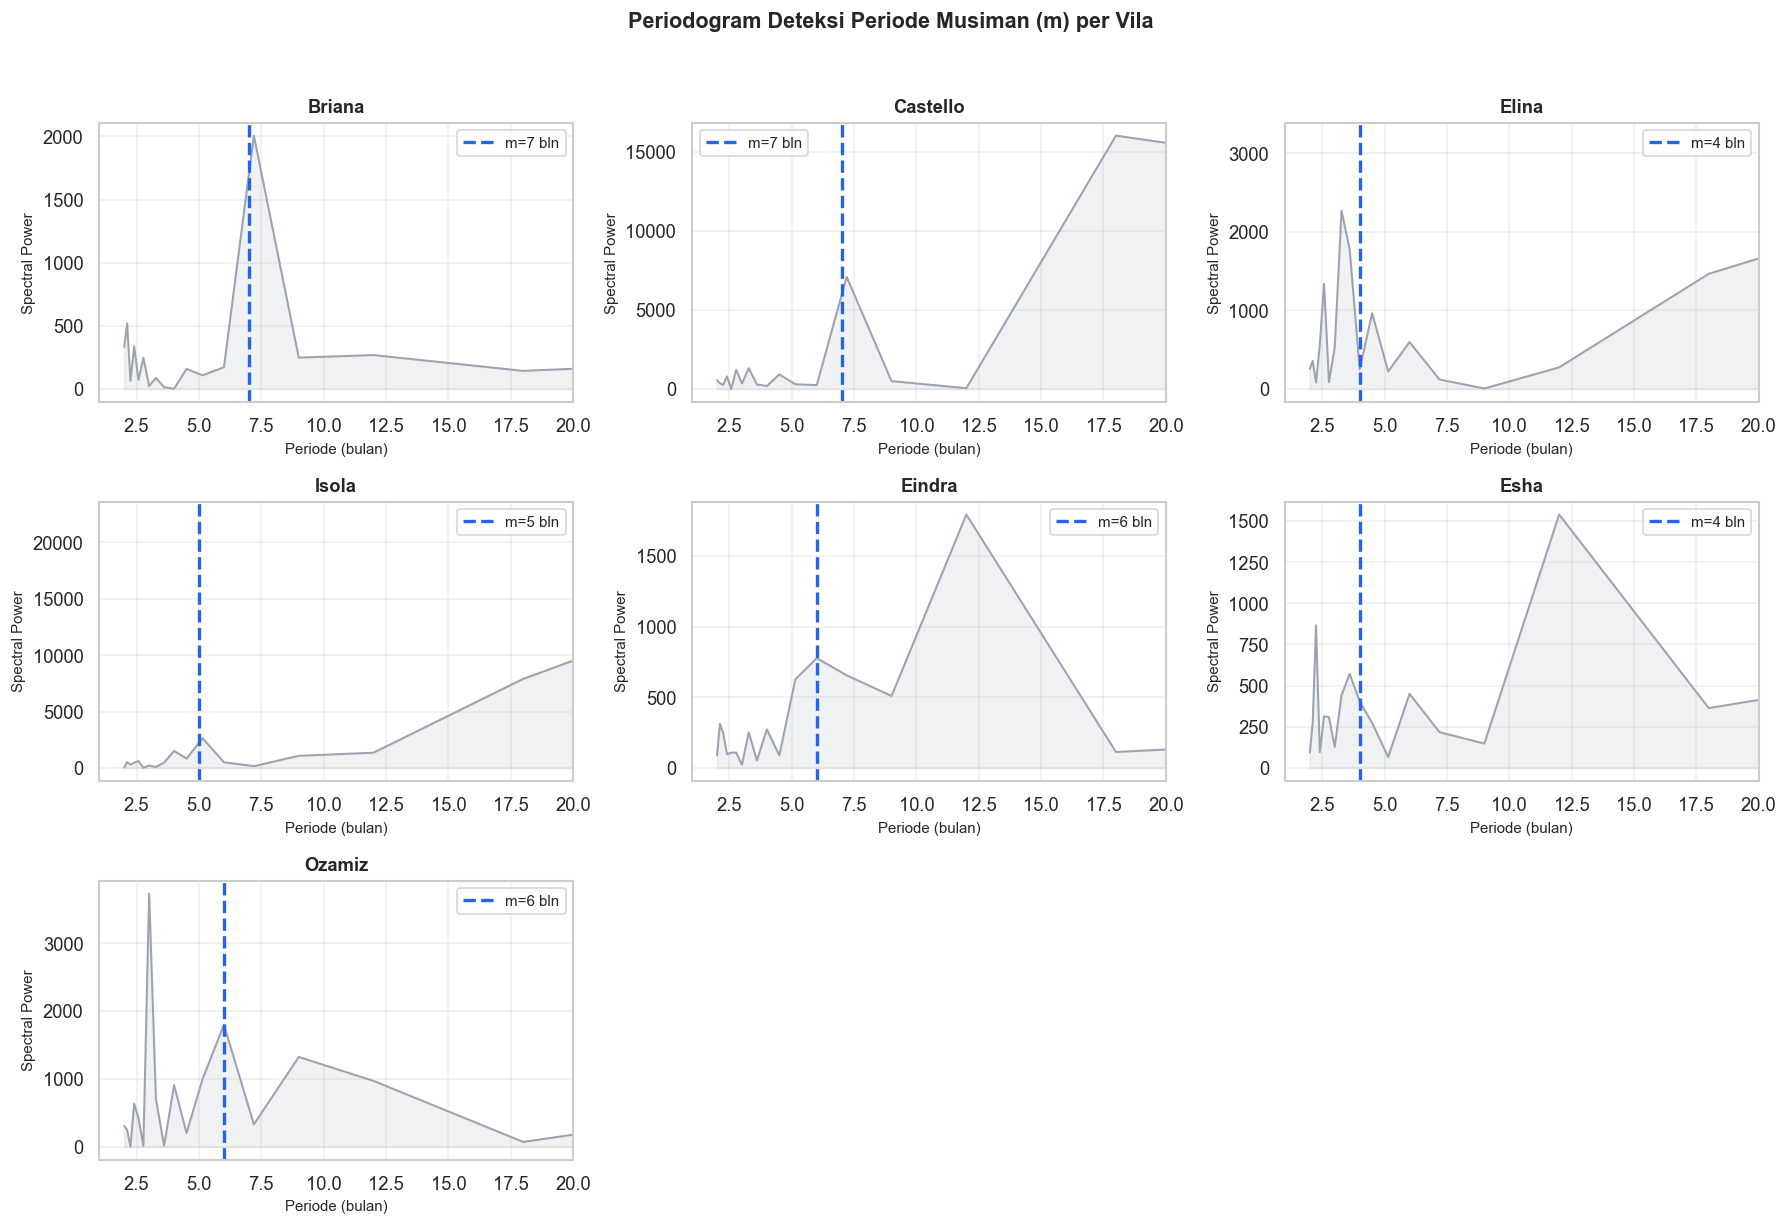

Grafik periodogram disimpan.

=== TABEL EKSAK UNTUK LAPORAN TUGAS AKHIR ===
Nama Vila  Kandidat m (Bulan)  Frekuensi (f)  Spectral Power                    Status Kesimpulan Akhir
   Briana             7 Bulan           0.14        2,006.82            Maksimum Lokal   m = 7 terpilih
 Castello     18 Bulan (Tren)           0.06       16,032.62 Diabaikan (Komponen Tren)   m = 7 terpilih
            7 Bulan (Musiman)           0.14        7,096.74    Maksimum Lokal Musiman                 
    Elina             4 Bulan           0.25          249.39            Maksimum Lokal   m = 4 terpilih
    Isola             5 Bulan           0.19        2,633.15            Maksimum Lokal   m = 5 terpilih
   Eindra     12 Bulan (Tren)           0.08        1,792.80 Diabaikan (Komponen Tren)   m = 6 terpilih
            6 Bulan (Musiman)           0.17          776.75    Maksimum Lokal Musiman                 
     Esha  12 Bulan (Tahunan)           0.08        1,539.46   Diabaikan (Overfitting)   m =

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

# Menampung data untuk tabel perbandingan kandidat m
tabel_data = []

for idx, (villa, series) in enumerate(clean_occ.items()):
    monthly = series.resample('MS').mean().dropna()
    title   = villa.replace('_villas', '').title()
    m_val   = villa_m[villa]

    freqs, power = scipy_periodogram(monthly.values)
    valid   = freqs[1:] > 0
    periods = 1.0 / freqs[1:][valid]
    pwr     = power[1:][valid]

    # Ambil spectral power pada periode tertentu, untuk dibandingkan di tabel
    def get_spec_data(target_p):
        idx_p = np.abs(periods - target_p).argmin()
        return round(periods[idx_p], 4), round(1.0 / periods[idx_p], 4), round(pwr[idx_p], 2)

    p_eksak, f_eksak, pwr_eksak = get_spec_data(m_val)

    if title == 'Briana':
        tabel_data.append({'Nama Vila': 'Briana', 'Kandidat m (Bulan)': '7 Bulan', 'Frekuensi (f)': f_eksak, 'Spectral Power': pwr_eksak, 'Status': 'Maksimum Lokal', 'Kesimpulan Akhir': 'm = 7 terpilih'})

    elif title == 'Castello':
        _, f_tren, pwr_tren = get_spec_data(18)  # nilai pada kisaran ujung grafik (komponen tren)
        tabel_data.append({'Nama Vila': 'Castello', 'Kandidat m (Bulan)': '18 Bulan (Tren)', 'Frekuensi (f)': f_tren, 'Spectral Power': pwr_tren, 'Status': 'Diabaikan (Komponen Tren)', 'Kesimpulan Akhir': 'm = 7 terpilih'})
        tabel_data.append({'Nama Vila': '', 'Kandidat m (Bulan)': '7 Bulan (Musiman)', 'Frekuensi (f)': f_eksak, 'Spectral Power': pwr_eksak, 'Status': 'Maksimum Lokal Musiman', 'Kesimpulan Akhir': ''})

    elif title == 'Elina':
        tabel_data.append({'Nama Vila': 'Elina', 'Kandidat m (Bulan)': '4 Bulan', 'Frekuensi (f)': f_eksak, 'Spectral Power': pwr_eksak, 'Status': 'Maksimum Lokal', 'Kesimpulan Akhir': 'm = 4 terpilih'})

    elif title == 'Isola':
        tabel_data.append({'Nama Vila': 'Isola', 'Kandidat m (Bulan)': '5 Bulan', 'Frekuensi (f)': f_eksak, 'Spectral Power': pwr_eksak, 'Status': 'Maksimum Lokal', 'Kesimpulan Akhir': 'm = 5 terpilih'})

    elif title == 'Eindra':
        _, f_tren, pwr_tren = get_spec_data(12)  # nilai pada kisaran puncak kanan
        tabel_data.append({'Nama Vila': 'Eindra', 'Kandidat m (Bulan)': '12 Bulan (Tren)', 'Frekuensi (f)': f_tren, 'Spectral Power': pwr_tren, 'Status': 'Diabaikan (Komponen Tren)', 'Kesimpulan Akhir': 'm = 6 terpilih'})
        tabel_data.append({'Nama Vila': '', 'Kandidat m (Bulan)': '6 Bulan (Musiman)', 'Frekuensi (f)': f_eksak, 'Spectral Power': pwr_eksak, 'Status': 'Maksimum Lokal Musiman', 'Kesimpulan Akhir': ''})

    elif title == 'Esha':
        _, f_tahunan, pwr_tahunan = get_spec_data(12)  # puncak tahunan yang diabaikan
        tabel_data.append({'Nama Vila': 'Esha', 'Kandidat m (Bulan)': '12 Bulan (Tahunan)', 'Frekuensi (f)': f_tahunan, 'Spectral Power': pwr_tahunan, 'Status': 'Diabaikan (Overfitting)', 'Kesimpulan Akhir': 'm = 4 terpilih'})
        tabel_data.append({'Nama Vila': '', 'Kandidat m (Bulan)': '4 Bulan (Kuartalan)', 'Frekuensi (f)': f_eksak, 'Spectral Power': pwr_eksak, 'Status': 'Maksimum Lokal Terpilih', 'Kesimpulan Akhir': ''})

    elif title == 'Ozamiz':
        _, f_noise, pwr_noise = get_spec_data(3)  # puncak noise frekuensi tinggi
        tabel_data.append({'Nama Vila': 'Ozamiz', 'Kandidat m (Bulan)': '3 Bulan', 'Frekuensi (f)': f_noise, 'Spectral Power': pwr_noise, 'Status': 'Noise Frekuensi Tinggi', 'Kesimpulan Akhir': 'm = 6 terpilih'})
        tabel_data.append({'Nama Vila': '', 'Kandidat m (Bulan)': '6 Bulan (Musiman)', 'Frekuensi (f)': f_eksak, 'Spectral Power': pwr_eksak, 'Status': 'Puncak Dominan Stabil', 'Kesimpulan Akhir': ''})

    ax = axes[idx]
    ax.plot(periods, pwr, color='#9CA3AF', linewidth=1.2)
    ax.fill_between(periods, pwr, alpha=0.15, color='#9CA3AF')
    ax.axvline(x=m_val, color='#2563EB', linestyle='--', linewidth=2,
               label=f'm={m_val} bln')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Periode (bulan)', fontsize=9)
    ax.set_ylabel('Spectral Power', fontsize=9)
    ax.set_xlim(1, 20)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Sembunyikan subplot kosong jika jumlah villa < 9
for idx in range(len(clean_occ), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Periodogram Deteksi Periode Musiman (m) per Vila',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('periodogram_semua_vila.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik periodogram disimpan.')

# Tabel eksak untuk laporan tugas akhir
df_eksak = pd.DataFrame(tabel_data)
print("\n=== TABEL EKSAK UNTUK LAPORAN TUGAS AKHIR ===")
print(df_eksak.to_string(index=False))

# Ekspor ke Excel agar formatting baris kosong tidak berantakan saat disalin ke Word
df_eksak.to_excel('tabel_eksak_periodogram.xlsx', index=False)
print('Tabel komparasi eksak disimpan ke file "tabel_eksak_periodogram.xlsx".')

In [14]:
# Ekspor tabel deteksi m ke file Excel
m_df.to_excel('tabel_deteksi_musiman_skripsi.xlsx', index=False)
print("Tabel berhasil diekspor. Silakan cek folder file Anda.")

Tabel berhasil diekspor. Silakan cek folder file Anda.


## 7c. ACF & PACF — Identifikasi Order SARIMA

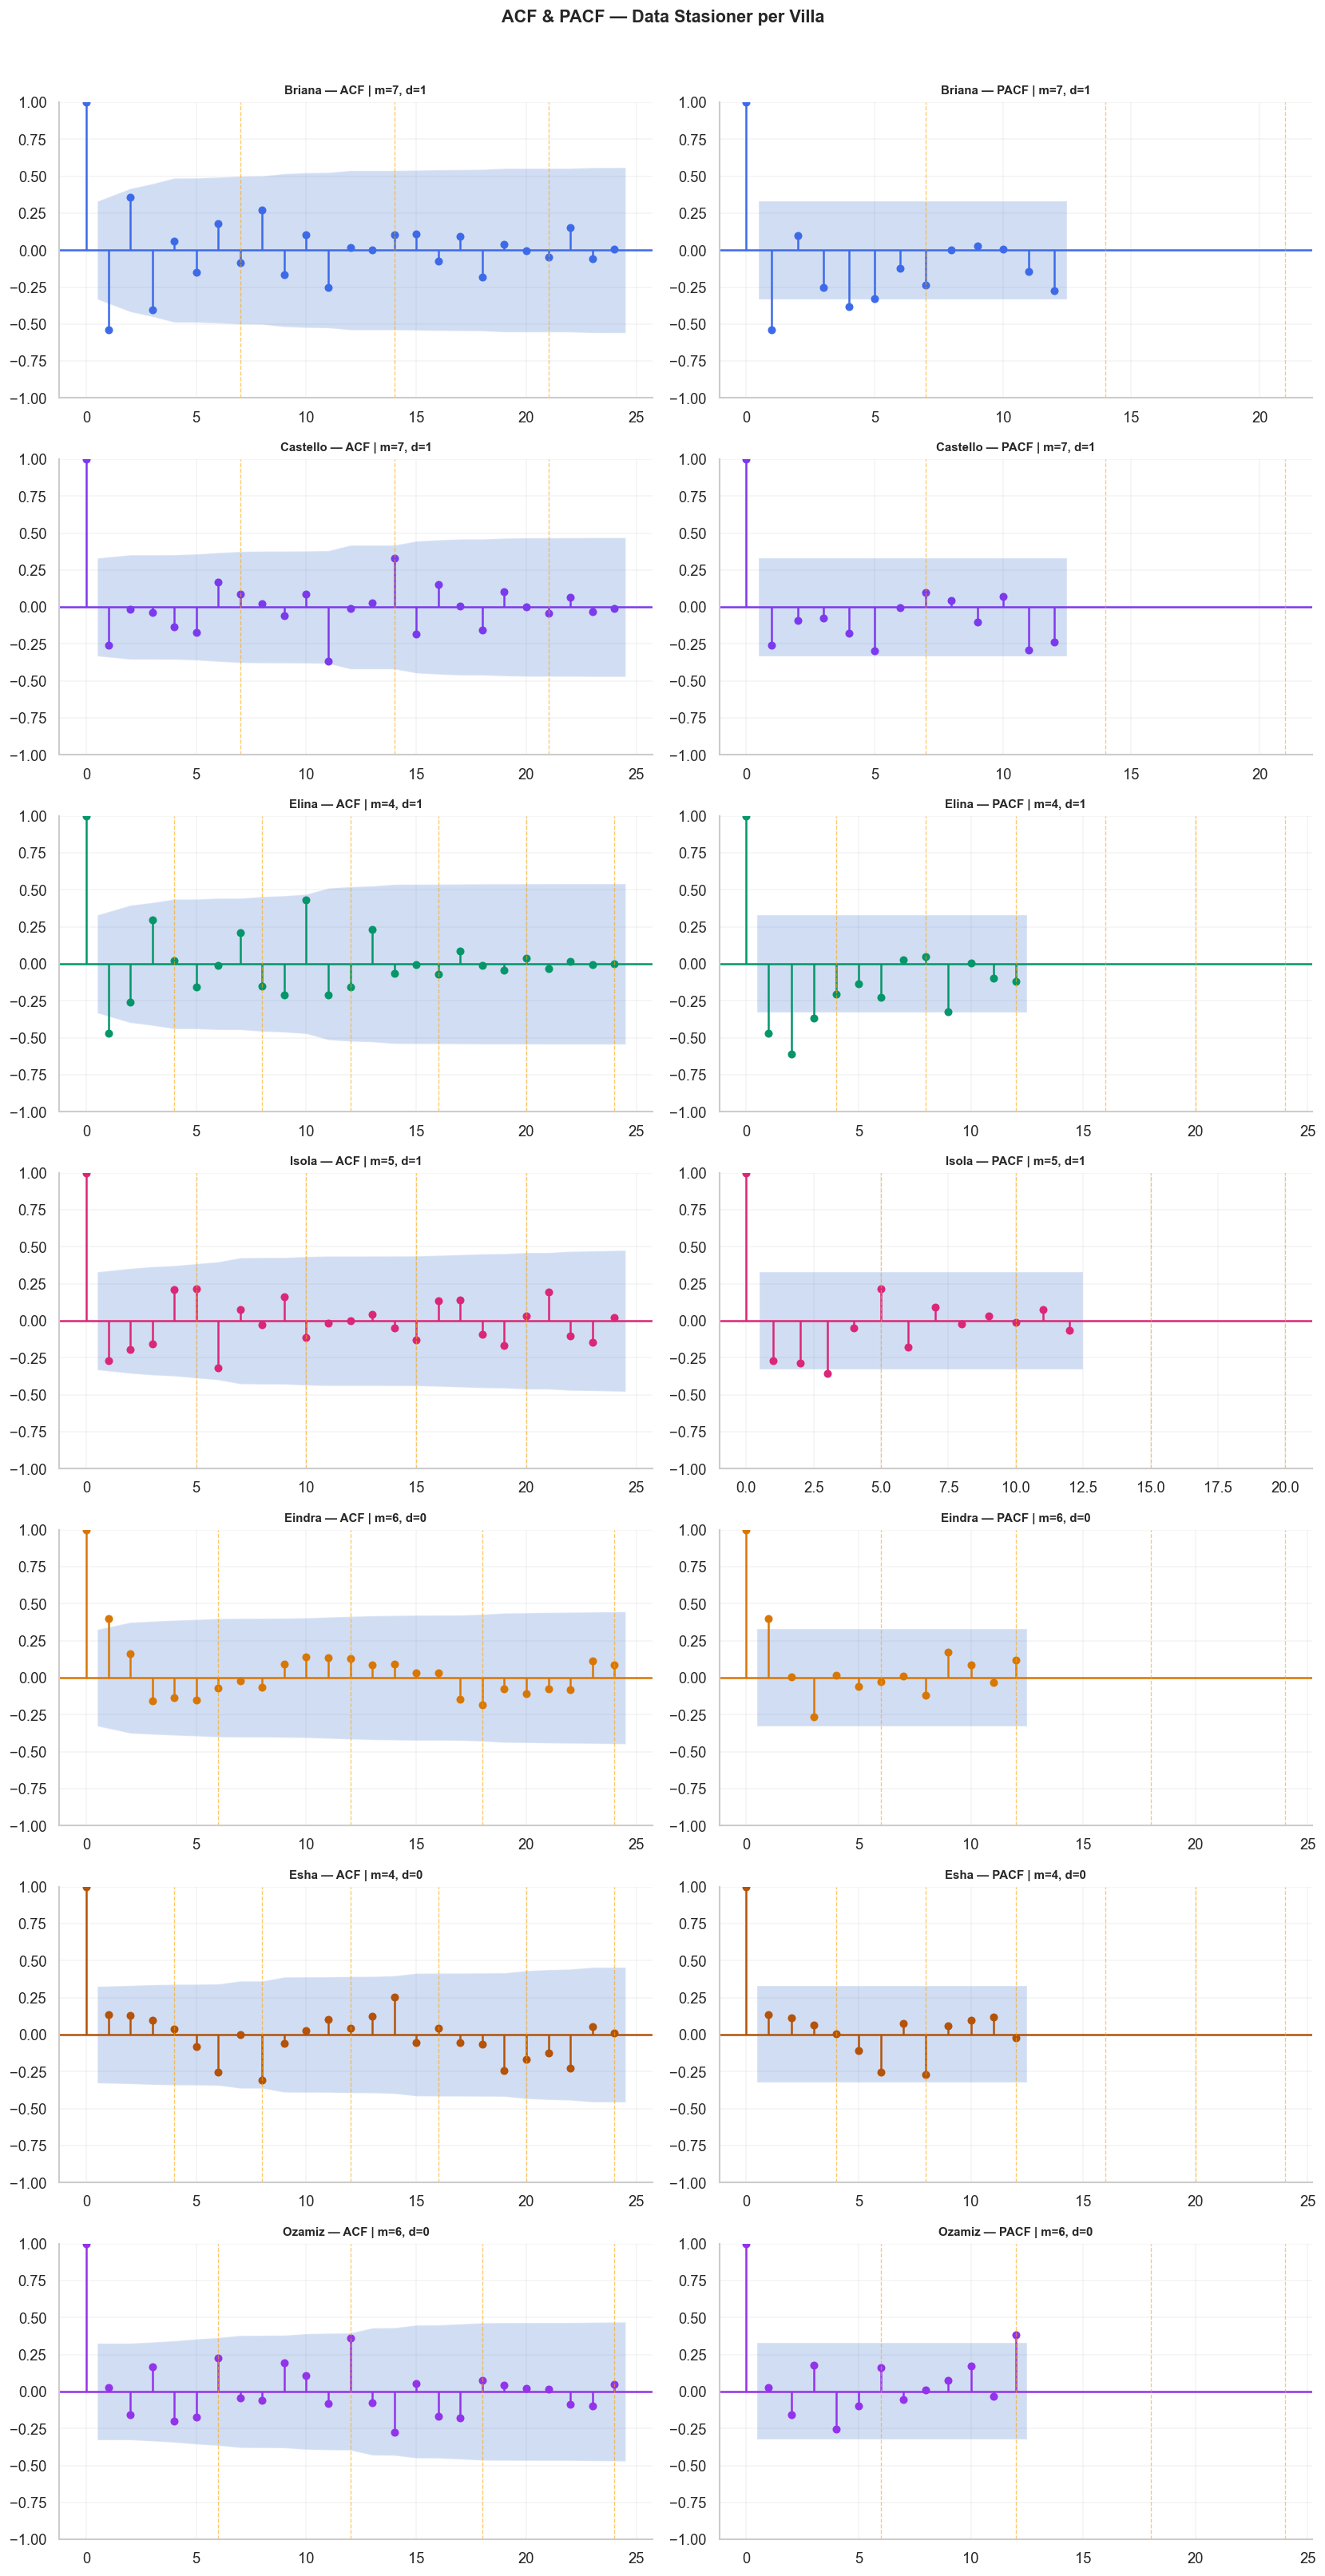

ACF & PACF selesai.


In [15]:
assert 'clean_occ_stationary' in dir(), 'Jalankan Cell 6 dulu'
assert 'villa_m' in dir(), 'Jalankan Cell 7b dulu'

n_villas = len(clean_occ_stationary)
fig, axes = plt.subplots(n_villas, 2, figsize=(14, 3.8 * n_villas))
if n_villas == 1:
    axes = [axes]

fig.suptitle('ACF & PACF — Data Stasioner per Villa',
             fontsize=13, fontweight='bold', y=1.01)

for ax_row, (villa, series) in zip(axes, clean_occ_stationary.items()):
    title  = villa.replace('_villas','').title()
    color  = VILLA_CONFIG[villa]['color']
    m_val  = villa_m[villa]
    d_val  = villa_d[villa]
    n      = len(series.dropna())

    max_lag_acf  = min(24, n - 1)
    max_lag_pacf = min(int(n / 2) - 1, 12)

    plot_acf(series.dropna(), lags=max_lag_acf, ax=ax_row[0],
             color=color, vlines_kwargs={'colors': color}, alpha=0.05, zero=True, title='')
    ax_row[0].set_title(f'{title} — ACF | m={m_val}, d={d_val}', fontsize=9, fontweight='bold')

    plot_pacf(series.dropna(), lags=max_lag_pacf, ax=ax_row[1],
              color=color, vlines_kwargs={'colors': color}, alpha=0.05,
              zero=True, method='ywm', title='')
    ax_row[1].set_title(f'{title} — PACF | m={m_val}, d={d_val}', fontsize=9, fontweight='bold')

    for ax in ax_row:
        for lag_mark in range(m_val, max_lag_acf + 1, m_val):
            ax.axvline(lag_mark, color='orange', lw=0.8, ls='--', alpha=0.6)
        ax.grid(alpha=0.2); ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('acf_pacf_stationary.png', dpi=150, bbox_inches='tight')
plt.show()
print('ACF & PACF selesai.')

## 8. Grid Search SARIMA

In [16]:
assert 'villa_d' in dir(), 'Jalankan Cell 6 dulu'
assert 'villa_m' in dir(), 'Jalankan Cell 7b dulu'

p_range = [0, 1, 2]
q_range = [0, 1, 2]
P_range = [0, 1, 2]
Q_range = [0, 1, 2]
combos  = list(itertools.product(p_range, q_range, P_range, Q_range))

grid_rows = []

print('GRID SEARCH SARIMA')
print(f'Total kombinasi per villa: {len(combos)} (p,q,P,Q dalam [0,1,2])')
print('d dan m dikunci dari ADF & Periodogram')
print('=' * 75)

for villa, series in clean_occ.items():
    title   = villa.replace('_villas','').title()
    area    = VILLA_CONFIG[villa]['area'].title()
    d_val   = villa_d[villa]
    m_val   = villa_m[villa]
    monthly = series.resample('MS').mean().dropna()
    n_bln   = len(monthly)
    max_m   = n_bln // 4

    # Penjelasan d dari ADF
    dasar_d = (
        f'ADF: data sudah stasioner -> d=0 (tidak perlu differencing)'
        if d_val == 0 else
        f'ADF: data tidak stasioner -> diff(1) membuat stasioner -> d=1 (d di-cap maks 1)'
    )

    # Penjelasan m dari periodogram
    metode_m = 'periodogram'
    if 'm_det_results' in dir():
        for r in m_det_results:
            if r['Villa'].lower() == title.lower():
                metode_m = r['Metode']
                break
    dasar_m = (
        f'Periodogram+ACF: m={m_val} terdeteksi sebagai frekuensi dominan '
        f'(metode={metode_m}, MAX_M={max_m} dari n={n_bln} bln)'
    )

    # Train/test split
    n_test    = 3
    split_idx = len(monthly) - n_test
    train     = monthly.iloc[:split_idx]
    test      = monthly.iloc[split_idx:]

    print(f'\n[{title}] | d={d_val} m={m_val} | train={len(train)} bln | test={len(test)} bln')

    success, failed = 0, 0
    t0 = time.time()

    for p, q, P, Q in combos:
        order          = (p, d_val, q)
        seasonal_order = (P, 1, Q, m_val)

        try:
            mod_train = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False)
            pred_mean = mod_train.get_forecast(steps=len(test)).predicted_mean.clip(0, 100)
            rmse_val  = calculate_rmse(test.values, pred_mean.values)
            smape_val = calculate_smape(test.values, pred_mean.values)

            mod_full  = SARIMAX(monthly, order=order, seasonal_order=seasonal_order,
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False)

            grid_rows.append({
                'Vila'          : title,
                'Area'          : area,
                'Order'         : str(order),
                'Seasonal Order': str(seasonal_order),
                'AIC'           : round(mod_full.aic, 2),
                'BIC'           : round(mod_full.bic, 2),
                'RMSE'          : round(rmse_val, 2),
                'SMAPE'         : round(smape_val, 2),
                'Train (bln)'   : len(train),
                'Test (bln)'    : len(test),
                'Step1_Dasar_d' : dasar_d,
                'Step2_Dasar_m' : dasar_m,
            })
            success += 1
        except Exception:
            failed += 1

    print(f'  {success} berhasil | {failed} skip | {round(time.time()-t0,1)}s')

    villa_df = pd.DataFrame([r for r in grid_rows if r['Vila'] == title])
    if not villa_df.empty:
        print(f'  Top 5 BIC:')
        print(villa_df.nsmallest(5, 'BIC')[
            ['Order','Seasonal Order','AIC','BIC','RMSE','SMAPE']
        ].to_string(index=False))

# Ranking BIC
grid_df = pd.DataFrame(grid_rows).sort_values(['Vila', 'BIC']).reset_index(drop=True)
grid_df['Rank_BIC'] = grid_df.groupby('Vila')['BIC'].rank(method='first', ascending=True).astype(int)

# Status terpilih vs lainnya
grid_df['Step3_Status'] = grid_df['Rank_BIC'].apply(
    lambda r: 'Terpilih (Rank #1 BIC)' if r == 1 else 'Model Lainnya'
)

# Narasi seleksi lengkap (hanya untuk model terpilih)
def build_step_seleksi(row):
    if row['Rank_BIC'] != 1:
        return ''
    return (
        f"[Step 1] Stasioneritas: {row['Step1_Dasar_d']}. "
        f"[Step 2] Musiman: {row['Step2_Dasar_m']}. "
        f"[Step 3] Grid search {len(combos)} kombinasi -> model ini BIC={row['BIC']} "
        f"(terkecil untuk {row['Vila']}). "
        f"[Step 4] Validasi Ljung-Box dilakukan di Cell 9 (model alternatif "
        f"dicoba jika residual tidak bersih)."
    )

grid_df['Step4_Narasi_Seleksi'] = grid_df.apply(build_step_seleksi, axis=1)

# Simpan CSV format normal
cols_normal = [
    'Vila', 'Area', 'Order', 'Seasonal Order',
    'AIC', 'BIC', 'RMSE', 'SMAPE',
    'Train (bln)', 'Test (bln)', 'Rank_BIC'
]
grid_df[cols_normal].to_csv('sarima_grid_search.csv', index=False)

# Simpan CSV dengan penjelasan step lengkap
cols_penjelasan = cols_normal + [
    'Step1_Dasar_d', 'Step2_Dasar_m',
    'Step3_Status', 'Step4_Narasi_Seleksi'
]
grid_df[cols_penjelasan].to_csv('sarima_grid_search_penjelasan.csv', index=False)

# Preview model terpilih
print('\n' + '=' * 75)
print('sarima_grid_search.csv tersimpan (format normal)')
print('sarima_grid_search_penjelasan.csv tersimpan (dengan step penjelasan)')
print('\nRingkasan model terpilih per villa:')
terpilih_df = grid_df[grid_df['Rank_BIC'] == 1][
    ['Vila', 'Order', 'Seasonal Order', 'BIC', 'RMSE', 'SMAPE', 'Step3_Status']
]
display(terpilih_df.reset_index(drop=True))

GRID SEARCH SARIMA
Total kombinasi per villa: 81 (p,q,P,Q dalam [0,1,2])
d dan m dikunci dari ADF & Periodogram

[Briana] | d=1 m=7 | train=33 bln | test=3 bln
  81 berhasil | 0 skip | 62.6s
  Top 5 BIC:
    Order Seasonal Order   AIC   BIC  RMSE  SMAPE
(2, 1, 1)   (0, 1, 1, 7) 10.00 14.72 62.29 136.84
(2, 1, 1)   (2, 1, 1, 7) 14.00 17.39 25.10  29.69
(2, 1, 1)   (1, 1, 1, 7) 12.00 17.67 62.29 136.84
(2, 1, 2)   (0, 1, 2, 7) 78.93 81.72 29.62  36.08
(1, 1, 2)   (1, 1, 2, 7) 80.36 83.15 33.29  41.28

[Castello] | d=1 m=7 | train=33 bln | test=3 bln
  81 berhasil | 0 skip | 62.7s
  Top 5 BIC:
    Order Seasonal Order    AIC    BIC  RMSE  SMAPE
(2, 1, 2)   (1, 1, 2, 7)  92.38  95.56 14.58  34.18
(2, 1, 2)   (0, 1, 1, 7)  91.19  96.53 53.89 104.61
(2, 1, 2)   (2, 1, 0, 7)  99.37 102.76 11.09  18.45
(2, 1, 2)   (2, 1, 2, 7) 100.18 103.76 13.52  27.61
(0, 1, 2)   (1, 1, 2, 7) 102.49 104.88  9.97  14.35

[Elina] | d=1 m=4 | train=33 bln | test=3 bln
  81 berhasil | 0 skip | 46.4s
  Top 5 BIC:

,Vila,Order,Seasonal Order,BIC,RMSE,SMAPE,Step3_Status
0,Briana,"(2, 1, 1)","(0, 1, 1, 7)",14.72,62.29,136.84,Terpilih (Rank #1 BIC)
1,Castello,"(2, 1, 2)","(1, 1, 2, 7)",95.56,14.58,34.18,Terpilih (Rank #1 BIC)
2,Eindra,"(0, 0, 2)","(0, 1, 2, 6)",130.78,6.01,6.94,Terpilih (Rank #1 BIC)
3,Elina,"(2, 1, 1)","(2, 1, 0, 4)",205.36,54.19,95.12,Terpilih (Rank #1 BIC)
4,Esha,"(2, 0, 1)","(2, 1, 0, 4)",191.47,9.48,10.83,Terpilih (Rank #1 BIC)
5,Isola,"(0, 1, 2)","(1, 1, 2, 5)",165.50,17.51,19.24,Terpilih (Rank #1 BIC)
6,Ozamiz,"(0, 0, 2)","(0, 1, 2, 6)",136.21,21.11,30.07,Terpilih (Rank #1 BIC)


## 9. Seleksi Model Otomatis — Top 10 BIC + Ljung-Box

In [17]:
import warnings, time, ast
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
warnings.filterwarnings('ignore')

def calculate_mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    mask = actual != 0  # menghindari pembagian dengan nol
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

# Threshold filter
AIC_MIN   = 50
MAPE_MAX  = 80
RMSE_MAX  = 50
LB_P_MIN  = 0.05

sarima_models  = {}
sarima_results = []
all_candidates_logs = []

SEP  = '=' * 120
DASH = '-' * 120

print('AUTO-SCREENING SARIMA — EVALUASI KESELURUHAN PER VILLA (MAPE)')
print(f'Filter Utama: AIC>={AIC_MIN} | MAPE<={MAPE_MAX}% | RMSE<={RMSE_MAX}% | Ljung-Box p-val>={LB_P_MIN}')
print(SEP)

for villa, series in clean_occ.items():
    t_start = time.time()
    title   = villa.replace('_villas','').title()
    area    = VILLA_CONFIG[villa]['area'].title()
    d_val   = villa_d[villa]
    m_val   = villa_m[villa]
    color   = VILLA_CONFIG[villa]['color']
    monthly = series.resample('MS').mean().dropna()

    print(f'\n{DASH}')
    print(f'{title} ({area}) | n={len(monthly)} bln | d={d_val} | m={m_val}')

    n_test    = max(int(len(monthly) * 0.20), 3)
    split_idx = len(monthly) - n_test
    train     = monthly.iloc[:split_idx]
    test      = monthly.iloc[split_idx:]

    villa_grid = grid_df[grid_df['Vila'].str.lower() == title.lower()].copy()
    villa_grid = villa_grid[(villa_grid['AIC'] >= AIC_MIN)]
    villa_top  = villa_grid.sort_values('BIC').head(10)

    selected_order, selected_seasonal, selected_model = None, None, None
    model_status = ''
    top_10_logs = []
    lb_lag = max(3, min(m_val, len(train) // 3))

    for rank, (_, row) in enumerate(villa_top.iterrows(), 1):
        curr_order    = ast.literal_eval(row['Order'])
        curr_seasonal = ast.literal_eval(row['Seasonal Order'])
        bic_val       = row['BIC']

        try:
            m_tr = SARIMAX(train, order=curr_order, seasonal_order=curr_seasonal,
                           enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

            pred_obj  = m_tr.get_forecast(steps=len(test))
            pred_mean = pred_obj.predicted_mean.clip(0, 100)

            rmse_cand = calculate_rmse(test.values, pred_mean.values)
            mape_cand = calculate_mape(test.values, pred_mean.values)

            if pred_mean.isna().any():
                continue

            lb_res = acorr_ljungbox(m_tr.resid.dropna(), lags=[lb_lag], return_df=True)
            lb_p   = float(lb_res['lb_pvalue'].iloc[0])

            cand_status = "ELIGIBLE (Ideal)" if (mape_cand <= MAPE_MAX and rmse_cand <= RMSE_MAX and lb_p > LB_P_MIN) else "BAD METRIC/RESID"

            top_10_logs.append([rank, str(curr_order), str(curr_seasonal), f"{bic_val:.1f}", f"{lb_p:.4f}", f"{rmse_cand:.1f}%", f"{mape_cand:.1f}%", cand_status])

            all_candidates_logs.append({
                'Vila': title, 'Area': area, 'Rank_BIC': rank, 'Order': str(curr_order), 'Seasonal_Order': str(curr_seasonal),
                'BIC': round(bic_val, 2), 'LB_p_value': round(lb_p, 4), 'RMSE': round(rmse_cand, 2), 'MAPE': round(mape_cand, 2), 'Kelayakan': cand_status
            })

            if selected_model is None or (cand_status == "ELIGIBLE (Ideal)" and "IDEAL" not in model_status):
                selected_order, selected_seasonal, selected_model = curr_order, curr_seasonal, m_tr
                model_status = f'IDEAL Rank #{rank}' if cand_status == "ELIGIBLE (Ideal)" else f'Fallback Rank #{rank}'

        except:
            continue

    if selected_model is None:
        selected_order, selected_seasonal = (1, d_val, 1), (0, 1, 1, m_val)
        selected_model = SARIMAX(train, order=selected_order, seasonal_order=selected_seasonal,
                                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        model_status = 'Emergency fallback'

    final_pred  = selected_model.get_forecast(steps=len(test))
    final_mean  = final_pred.predicted_mean.clip(0, 100)
    final_rmse  = calculate_rmse(test.values, final_mean.values)
    final_mape  = calculate_mape(test.values, final_mean.values)

    print(f' FINAL MODEL: SARIMA{selected_order}×{selected_seasonal} | MAPE = {final_mape:.2f}%')

    model_full = SARIMAX(monthly, order=selected_order, seasonal_order=selected_seasonal,
                         enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

    sarima_models[villa] = {
        'model': model_full, 'train': train, 'test': test, 'pred_mean': final_mean,
        'train_fitted': selected_model.fittedvalues.clip(0, 100), 'rmse': final_rmse, 'mape': final_mape,
        'order': selected_order, 'seasonal_order': selected_seasonal, 'color': color
    }

    sarima_results.append({
        'Vila': title, 'Order': str(selected_order), 'BIC': round(model_full.bic, 2), 'RMSE': round(final_rmse, 2), 'MAPE': round(final_mape, 2)
    })

# Simpan CSV
pd.DataFrame(sarima_results).to_csv('sarima_model_results.csv', index=False, encoding='utf_8_sig')
pd.DataFrame(all_candidates_logs).to_csv('sarima_all_candidates_perf.csv', index=False, encoding='utf_8_sig')
print('\nFile CSV berhasil disimpan.')

AUTO-SCREENING SARIMA — EVALUASI KESELURUHAN PER VILLA (MAPE)
Filter Utama: AIC>=50 | MAPE<=80% | RMSE<=50% | Ljung-Box p-val>=0.05

------------------------------------------------------------------------------------------------------------------------
Briana (Canggu) | n=36 bln | d=1 | m=7
 FINAL MODEL: SARIMA(2, 1, 2)×(0, 1, 2, 7) | MAPE = 19.21%

------------------------------------------------------------------------------------------------------------------------
Castello (Canggu) | n=36 bln | d=1 | m=7
 FINAL MODEL: SARIMA(2, 1, 2)×(1, 1, 2, 7) | MAPE = 57.46%

------------------------------------------------------------------------------------------------------------------------
Elina (Canggu) | n=36 bln | d=1 | m=4
 FINAL MODEL: SARIMA(2, 1, 1)×(2, 1, 0, 4) | MAPE = 184.38%

------------------------------------------------------------------------------------------------------------------------
Isola (Canggu) | n=36 bln | d=1 | m=5
 FINAL MODEL: SARIMA(0, 1, 2)×(1, 1, 2, 5) | M

## 10. Forecast +6 Bulan


[Briana] refit 36 bln -> forecast 6 bln | m=7


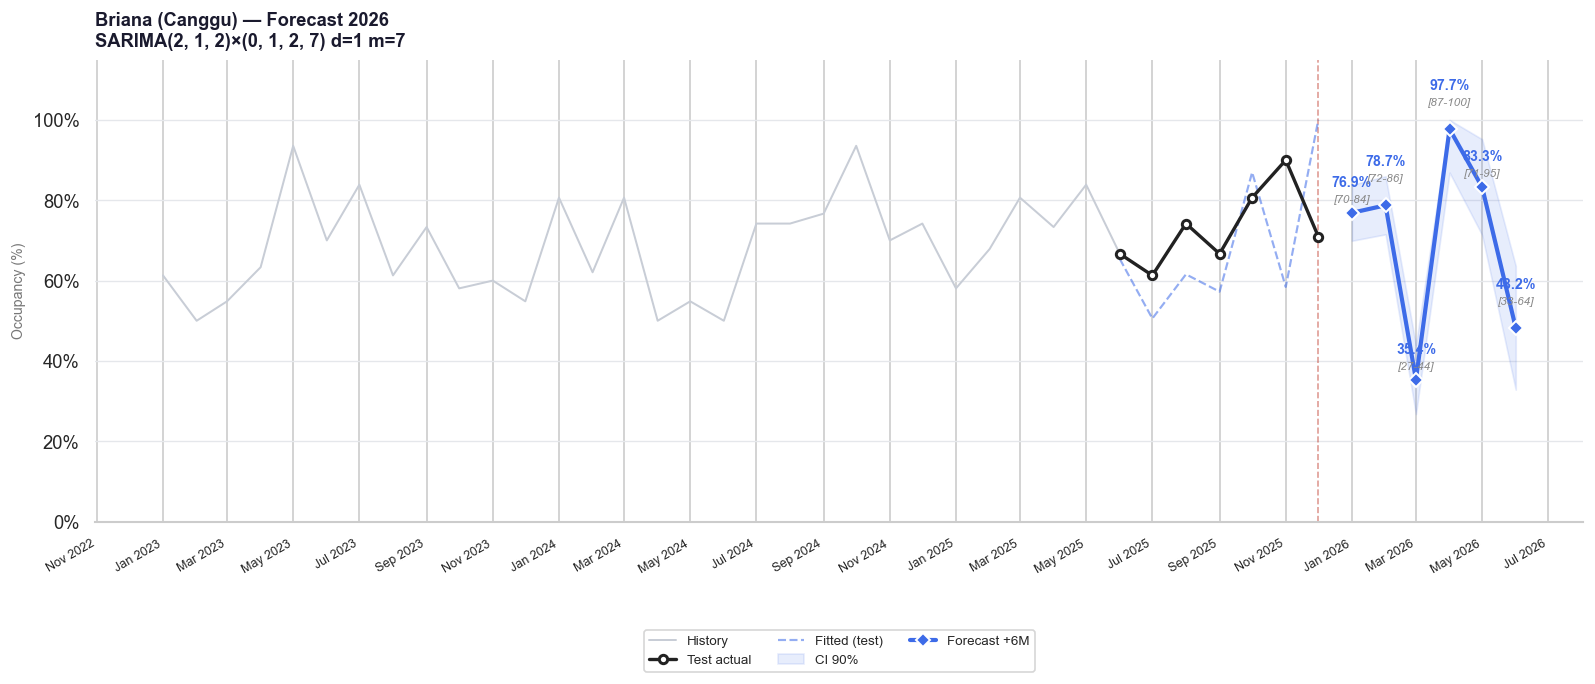


[Castello] refit 36 bln -> forecast 6 bln | m=7


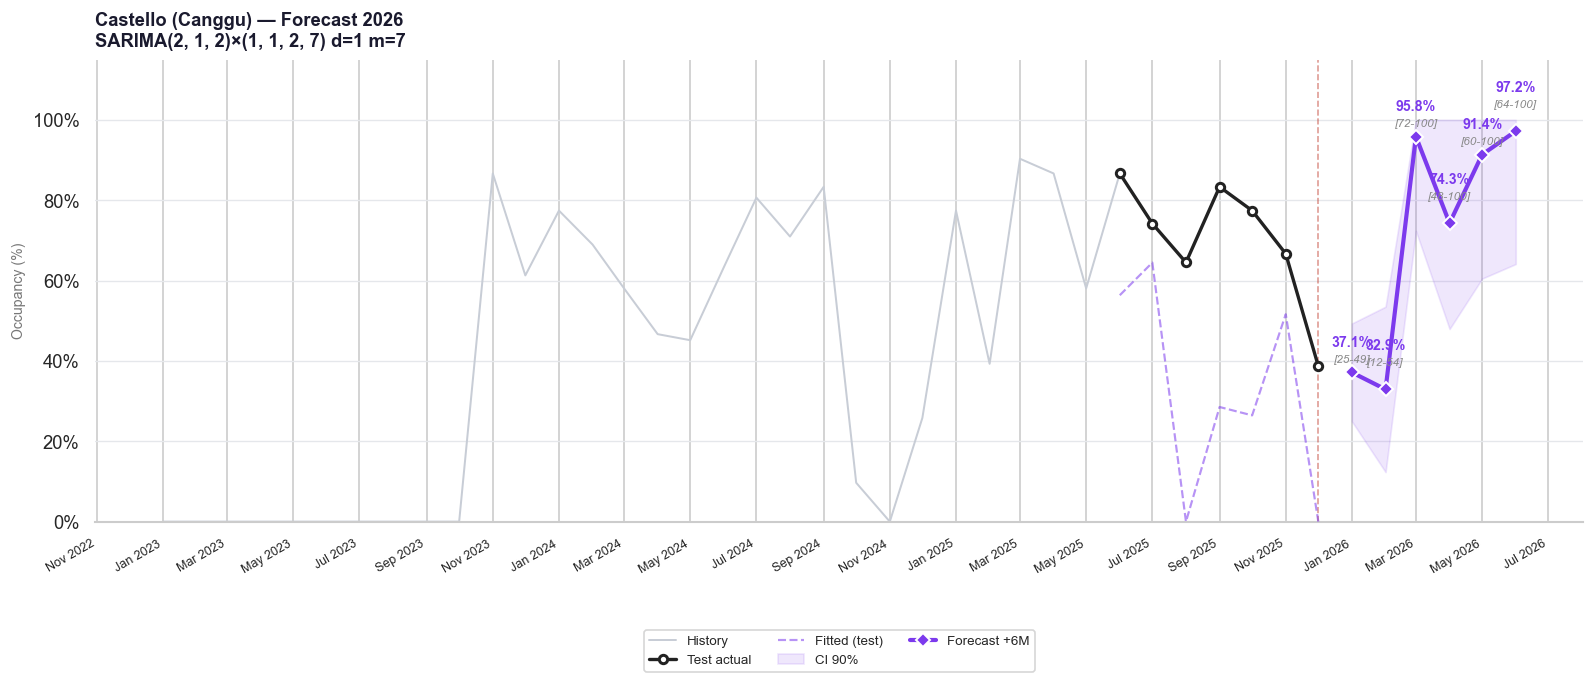


[Elina] refit 36 bln -> forecast 6 bln | m=4


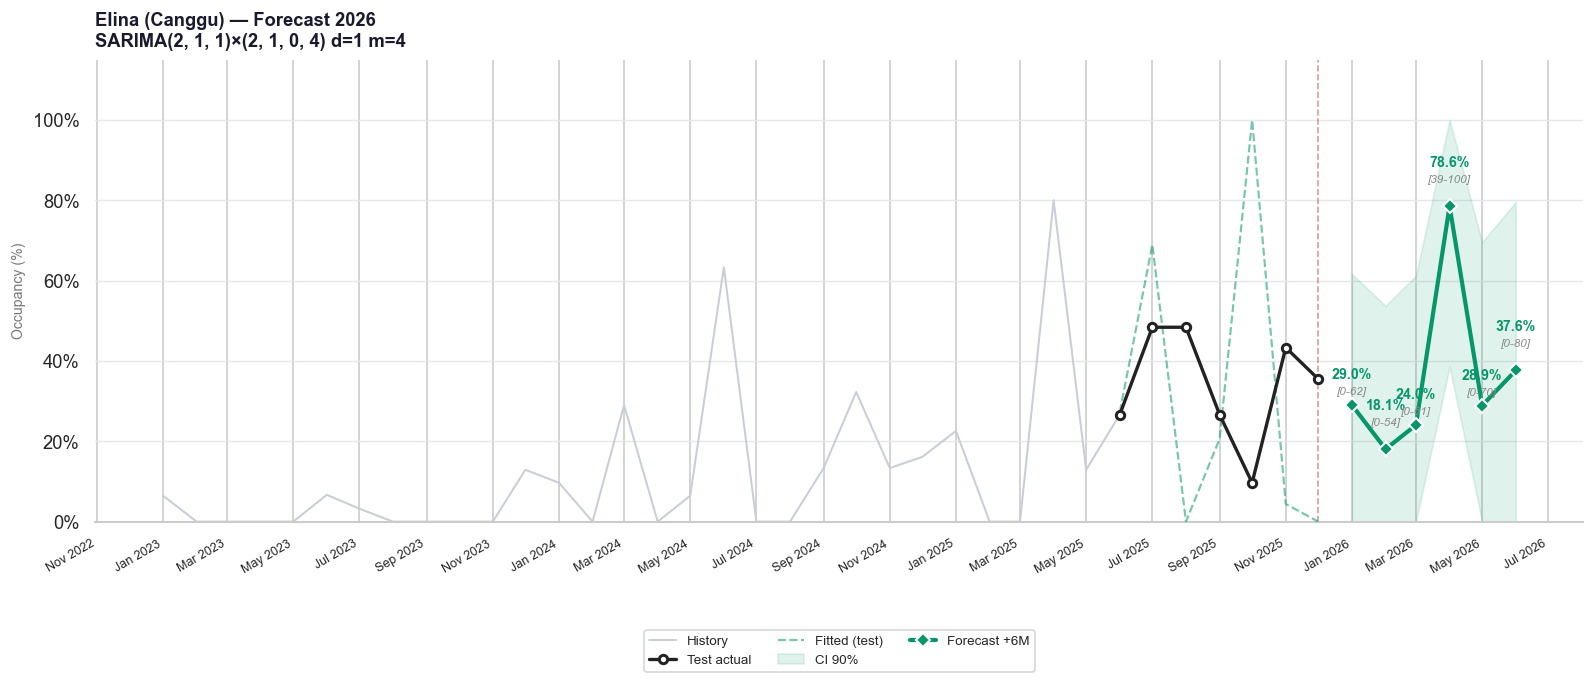


[Isola] refit 36 bln -> forecast 6 bln | m=5


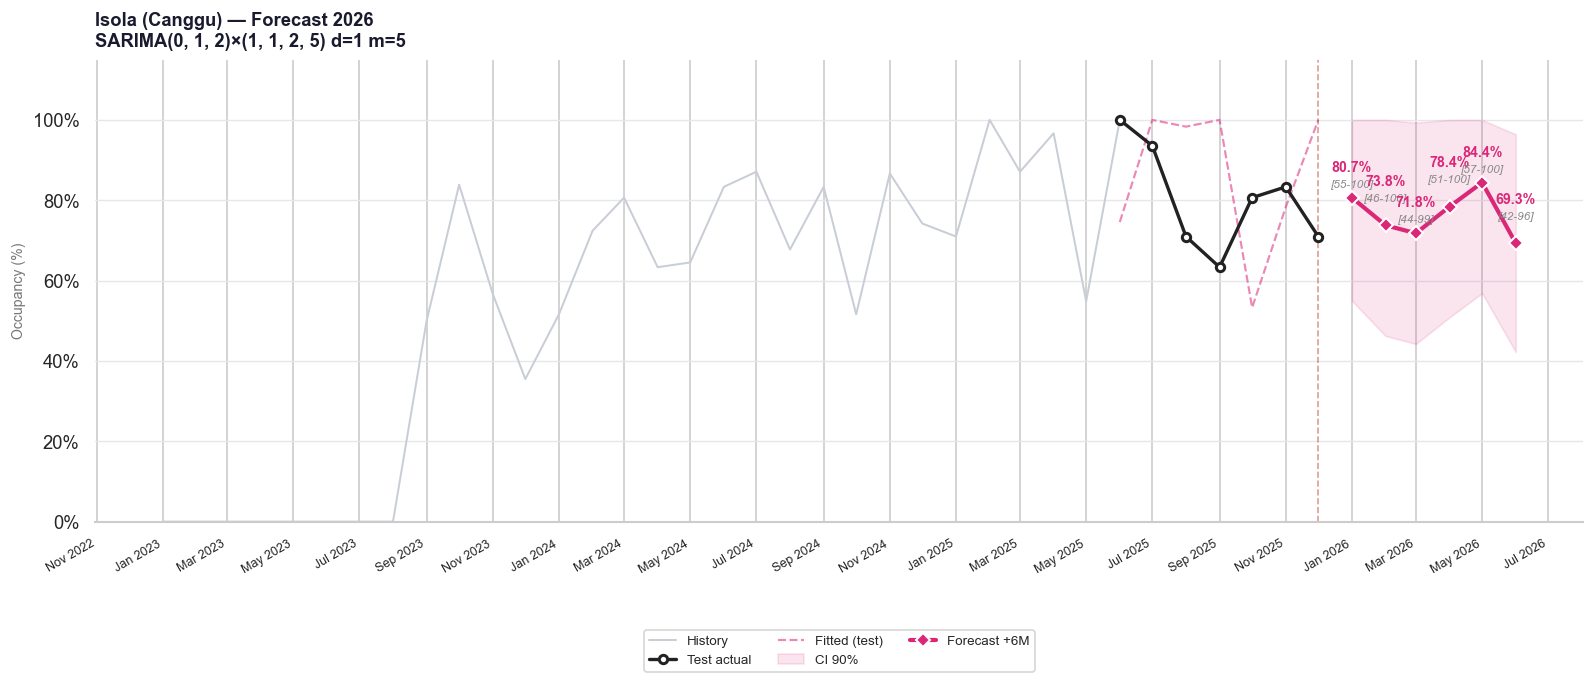


[Eindra] refit 36 bln -> forecast 6 bln | m=6


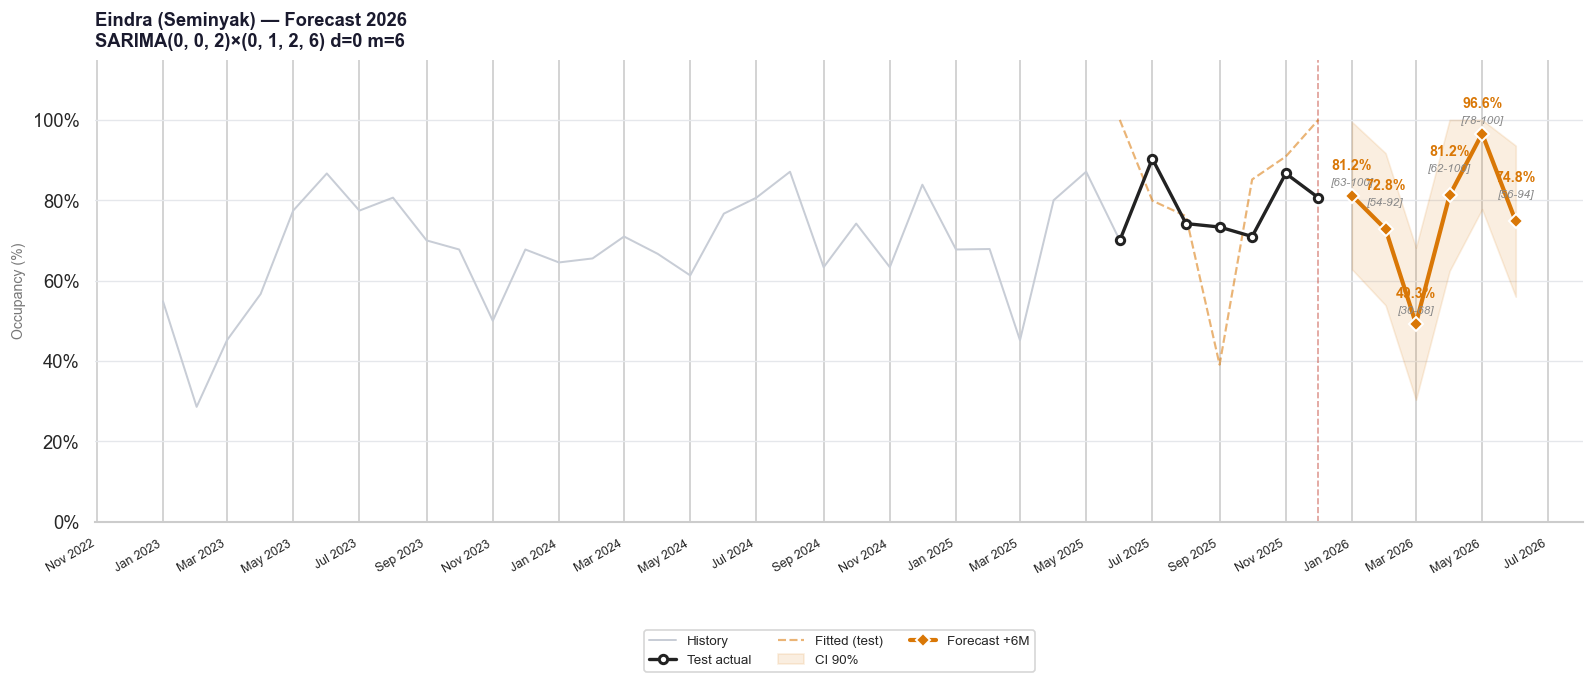


[Esha] refit 36 bln -> forecast 6 bln | m=4


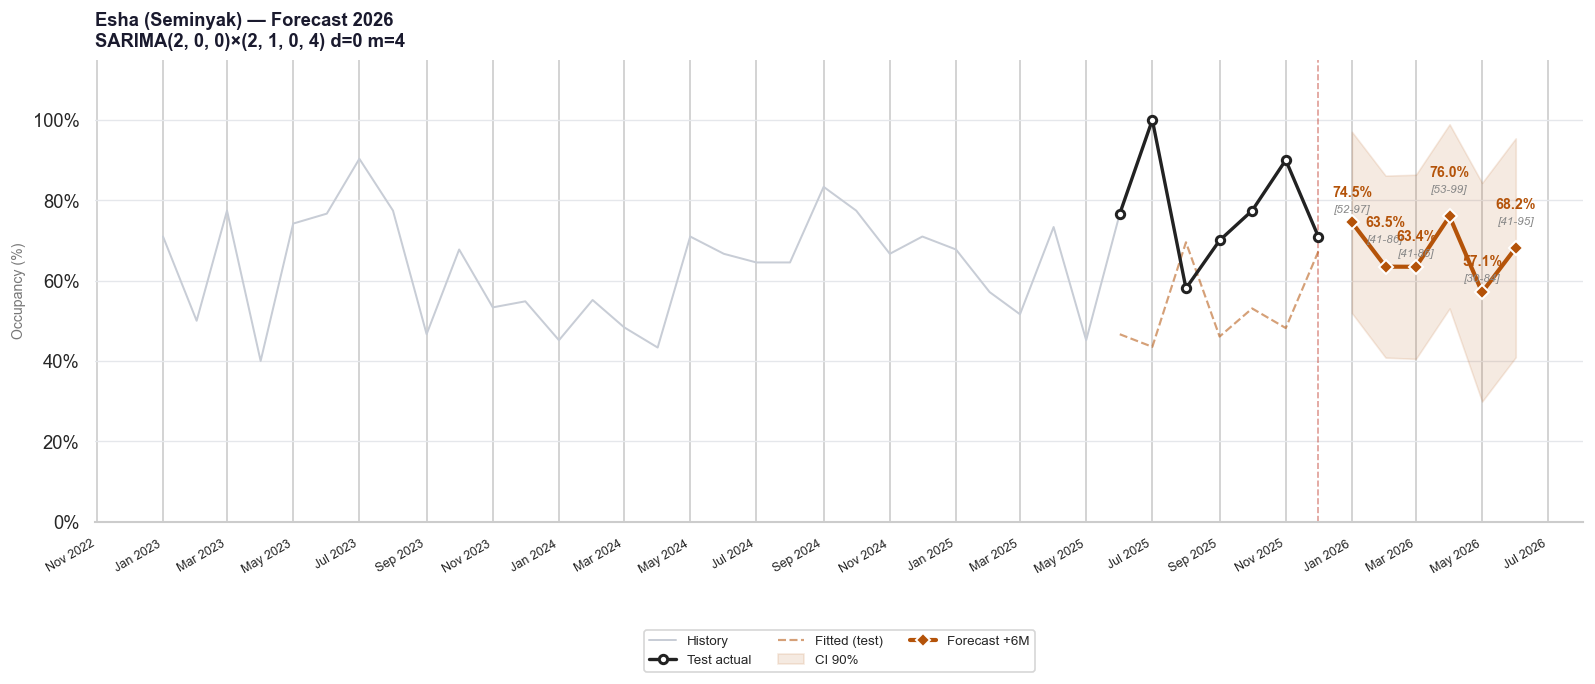


[Ozamiz] refit 36 bln -> forecast 6 bln | m=6


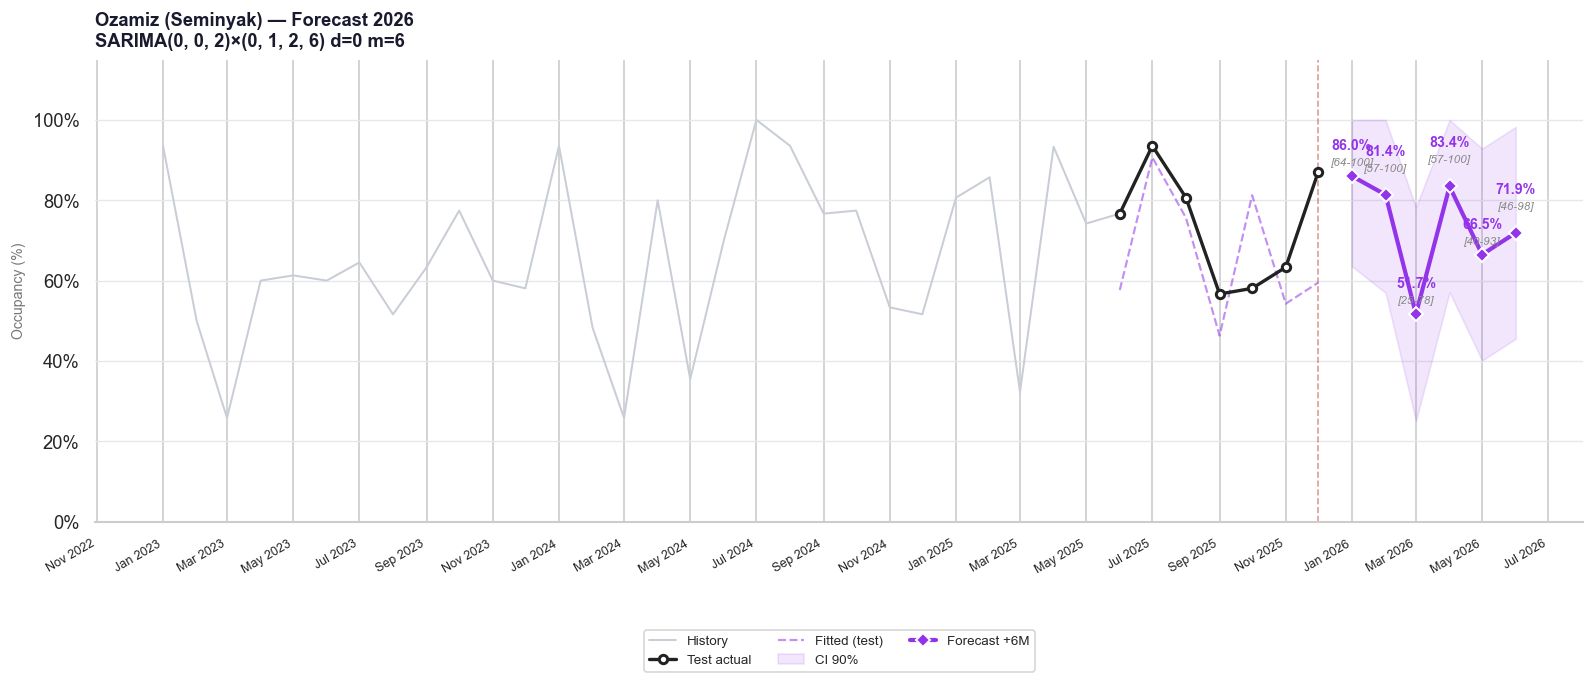

FORECAST OCCUPANCY +6 BULAN


Area  Forecast (%)  Lower CI 90%  Upper CI 90%  \
Villa    Bulan                                                          
Briana   Jan 2026    Canggu         76.90         69.90         83.80   
         Feb 2026    Canggu         78.70         71.50         86.00   
         Mar 2026    Canggu         35.40         26.80         44.00   
         Apr 2026    Canggu         97.70         86.90        100.00   
         May 2026    Canggu         83.30         71.40         95.20   
         Jun 2026    Canggu         48.20         32.80         63.70   
Castello Jan 2026    Canggu         37.10         25.00         49.30   
         Feb 2026    Canggu         32.90         12.30         53.50   
         Mar 2026    Canggu         95.80         72.40        100.00   
         Apr 2026    Canggu         74.30         48.00        100.00   
         May 2026    Canggu         91.40         60.50        100.00   
         Jun 2026    Canggu         97.20         64.10        100.00   
Elina    Jan 2026    Canggu         29.00          0.00         61.60   
         Feb 2026    Canggu         18.10          0.00         53.70   
         Mar 2026    Canggu         24.00          0.00         61.20   
         Apr 2026    Canggu         78.60         38.50        100.00   
         May 2026    Canggu         28.90          0.00         69.50   
         Jun 2026    Canggu         37.60          0.00         79.60   
Isola    Jan 2026    Canggu         80.70         55.00        100.00   
         Feb 2026    Canggu         73.80         46.20        100.00   
         Mar 2026    Canggu         71.80         44.20         99.30   
         Apr 2026    Canggu         78.40         50.90        100.00   
         May 2026    Canggu         84.40         56.90        100.00   
         Jun 2026    Canggu         69.30         42.20         96.40   
Eindra   Jan 2026  Seminyak         81.20         62.80         99.50   
         Feb 2026  Seminyak         72.80         53.90         91.70   
         Mar 2026  Seminyak         49.30         30.30         68.20   
         Apr 2026  Seminyak         81.20         62.40        100.00   
         May 2026  Seminyak         96.60         77.80        100.00   
         Jun 2026  Seminyak         74.80         56.00         93.60   
Esha     Jan 2026  Seminyak         74.50         51.90         97.00   
         Feb 2026  Seminyak         63.50         40.80         86.10   
         Mar 2026  Seminyak         63.40         40.50         86.30   
         Apr 2026  Seminyak         76.00         53.10         98.90   
         May 2026  Seminyak         57.10         29.90         84.30   
         Jun 2026  Seminyak         68.20         40.90         95.40   
Ozamiz   Jan 2026  Seminyak         86.00         63.50        100.00   
         Feb 2026  Seminyak         81.40         57.00        100.00   
         Mar 2026  Seminyak         51.70         25.10         78.20   
         Apr 2026  Seminyak         83.40         57.10        100.00   
         May 2026  Seminyak         66.50         40.10         92.90   
         Jun 2026  Seminyak         71.90         45.50         98.30   

                   Rentang CI  Flat?  
Villa    Bulan                        
Briana   Jan 2026       13.90  Tidak  
         Feb 2026       14.50  Tidak  
         Mar 2026       17.20  Tidak  
         Apr 2026       13.10  Tidak  
         May 2026       23.80  Tidak  
         Jun 2026       30.80  Tidak  
Castello Jan 2026       24.40  Tidak  
         Feb 2026       41.20  Tidak  
         Mar 2026       27.60  Tidak  
         Apr 2026       52.00  Tidak  
         May 2026       39.50  Tidak  
         Jun 2026       35.90  Tidak  
Elina    Jan 2026       61.60  Tidak  
         Feb 2026       53.70  Tidak  
         Mar 2026       61.20  Tidak  
         Apr 2026       61.50  Tidak  
         May 2026       69.50  Tidak  
         Jun 2026       79.60  Tidak  
Isola    Jan 2026       45.00 


forecast_occupancy_2026.csv tersimpan.
Bervariansi (7): ['Briana', 'Castello', 'Elina', 'Isola', 'Eindra', 'Esha', 'Ozamiz']


In [18]:
FORECAST_STEPS  = 6
FLAT_STD_THRESH = 1.5

forecast_rows = []
flat_villas   = []

for villa, info in sarima_models.items():
    order   = info['order']
    s_order = info['seasonal_order']
    monthly = pd.concat([info['train'], info['test']])
    d       = order[1]
    m_used  = s_order[3]
    color   = VILLA_CONFIG[villa]['color']
    title   = villa.replace('_villas','').title()
    area    = VILLA_CONFIG[villa]['area'].title()

    print(f'\n[{title}] refit {len(monthly)} bln -> forecast {FORECAST_STEPS} bln | m={m_used}')

    try:
        model_full = SARIMAX(monthly, order=order, seasonal_order=s_order,
                             enforce_stationarity=False,
                             enforce_invertibility=False).fit(disp=False)
    except Exception:
        model_full = info['model']

    fore_obj  = model_full.get_forecast(steps=FORECAST_STEPS)
    fore_mean = fore_obj.predicted_mean.clip(0, 100)
    fore_ci   = fore_obj.conf_int(alpha=0.10).clip(0, 100)
    fore_std  = fore_mean.std()

    used_s_order = s_order
    if fore_std < FLAT_STD_THRESH:
        print(f'  Flat (std={fore_std:.2f}%) -> retry seasonal...')
        best_aic = model_full.aic; best_model = model_full
        best_fore = fore_mean; best_ci = fore_ci; best_sorder = s_order

        for s_cand in [(1,0,0,m_used),(0,0,1,m_used),(1,0,1,m_used)]:
            try:
                mc = SARIMAX(monthly, order=(order[0], d, order[2]),
                             seasonal_order=s_cand,
                             enforce_stationarity=False,
                             enforce_invertibility=False).fit(disp=False)
                fc = mc.get_forecast(steps=FORECAST_STEPS)
                fm = fc.predicted_mean.clip(0, 100)
                fi = fc.conf_int(alpha=0.10).clip(0, 100)
                std_c = fm.std()
                print(f'     {s_cand}: std={std_c:.2f}%', end='')
                if std_c > FLAT_STD_THRESH and mc.aic < best_aic + 10:
                    best_aic = mc.aic; best_model = mc
                    best_fore = fm; best_ci = fi; best_sorder = s_cand
                    print(' (selected)')
                else:
                    print()
            except Exception:
                continue

        model_full = best_model; used_s_order = best_sorder
        fore_mean = best_fore; fore_ci = best_ci; fore_std = fore_mean.std()
        if fore_std < FLAT_STD_THRESH:
            flat_villas.append(title)

    is_flat = fore_std < FLAT_STD_THRESH

    for date, val, lo, hi in zip(fore_mean.index, fore_mean.values,
                                  fore_ci.iloc[:,0].values, fore_ci.iloc[:,1].values):
        forecast_rows.append({
            'Villa': title, 'Area': area,
            'Bulan': date.strftime('%b %Y'),
            'Forecast (%)': round(val, 1),
            'Lower CI 90%': round(lo, 1),
            'Upper CI 90%': round(hi, 1),
            'Rentang CI'  : round(hi - lo, 1),
            'Flat?'       : 'Ya' if is_flat else 'Tidak',
        })

    fore_color = '#E24B4A' if is_flat else color

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(monthly.index, monthly.values, color='#c8cdd6', lw=1.2, label='History')
    ax.plot(info['test'].index, info['test'].values, color='#222', lw=2,
            marker='o', ms=5, markerfacecolor='white', markeredgewidth=1.8,
            zorder=4, label='Test actual')
    ax.plot(info['pred_mean'].index, info['pred_mean'].values,
            color=color, lw=1.3, ls='--', alpha=0.55, zorder=3, label='Fitted (test)')
    ax.fill_between(fore_ci.index, fore_ci.iloc[:,0], fore_ci.iloc[:,1],
                    color=fore_color, alpha=0.12, zorder=2, label='CI 90%')
    ax.plot(fore_mean.index, fore_mean.values, color=fore_color, lw=2.5,
            marker='D', ms=6, markerfacecolor=fore_color,
            markeredgecolor='white', markeredgewidth=1.2,
            zorder=5, label=f'Forecast +{FORECAST_STEPS}M')

    for i, (dt, val, lo, hi) in enumerate(zip(fore_mean.index, fore_mean.values,
                                               fore_ci.iloc[:,0].values, fore_ci.iloc[:,1].values)):
        base_off = 14 if i % 2 == 0 else 22
        ax.annotate(f'{val:.1f}%', xy=(dt, val), xytext=(0, base_off),
                    textcoords='offset points', ha='center', va='bottom',
                    fontsize=8.5, fontweight='bold', color=fore_color, zorder=6)
        ax.annotate(f'[{lo:.0f}-{hi:.0f}]', xy=(dt, val), xytext=(0, base_off - 9),
                    textcoords='offset points', ha='center', va='bottom',
                    fontsize=7, color='#888', style='italic', zorder=6)

    ax.axvline(monthly.index[-1], color='#c0392b', ls='--', lw=1.0, alpha=0.5)
    ax.set_title(f'{title} ({area}) — Forecast 2026\nSARIMA{order}×{used_s_order} d={d} m={m_used}',
                 fontsize=11, fontweight='bold', loc='left', color='#1a1a2e', pad=8)
    ax.set_ylabel('Occupancy (%)', fontsize=8.5, color='#777')
    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7.5)
    ax.grid(axis='y', color='#e5e7eb', lw=0.8)
    ax.spines[['top','right','left']].set_visible(False)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=3, fontsize=8)
    plt.savefig(f'forecast_2026_{villa}.png', dpi=180, bbox_inches='tight', facecolor='white')
    plt.show(); plt.close(fig)

forecast_df = pd.DataFrame(forecast_rows)
print('=' * 75)
print(f'FORECAST OCCUPANCY +{FORECAST_STEPS} BULAN')
print('=' * 75)
display(forecast_df.set_index(['Villa','Bulan']))
forecast_df.to_csv('forecast_occupancy_2026.csv', index=False)
print('\nforecast_occupancy_2026.csv tersimpan.')

ok_villas = [v for v in [v.replace('_villas','').title() for v in sarima_models]
             if v not in flat_villas]
print(f'Bervariansi ({len(ok_villas)}): {ok_villas}')
if flat_villas:
    print(f'Flat ({len(flat_villas)}): {flat_villas}')

## 11. Evaluasi Model — RMSE & SMAPE

EVALUASI MODEL SARIMA: RMSE & MAPE

Briana (Canggu)
   Model  : SARIMA(2, 1, 2)×(0, 1, 2, 7)
   Test   -> RMSE = 17.91%   |  MAPE = 19.21%   |  Good
   Train  -> RMSE = 23.41%  |  MAPE = 28.04%  |  OK

Castello (Canggu)
   Model  : SARIMA(2, 1, 2)×(1, 1, 2, 7)
   Test   -> RMSE = 42.26%   |  MAPE = 57.46%   |  Poor
   Train  -> RMSE = 25.35%  |  MAPE = 40.30%  |  Overfit

Elina (Canggu)
   Model  : SARIMA(2, 1, 1)×(2, 1, 0, 4)
   Test   -> RMSE = 44.29%   |  MAPE = 184.38%   |  Poor
   Train  -> RMSE = 10.13%  |  MAPE = 44.87%  |  Overfit

Isola (Canggu)
   Model  : SARIMA(0, 1, 2)×(1, 1, 2, 5)
   Test   -> RMSE = 25.06%   |  MAPE = 29.95%   |  Fair
   Train  -> RMSE = 19.40%  |  MAPE = 22.60%  |  OK

Eindra (Seminyak)
   Model  : SARIMA(0, 0, 2)×(0, 1, 2, 6)
   Test   -> RMSE = 19.93%   |  MAPE = 21.78%   |  Fair
   Train  -> RMSE = 32.12%  |  MAPE = 36.54%  |  OK

Esha (Seminyak)
   Model  : SARIMA(2, 0, 0)×(2, 1, 0, 4)
   Test   -> RMSE = 31.96%   |  MAPE = 33.25%   |  Fair
   Train

,Bulan,Aktual y_i (%),Prediksi ŷ_i (%),Error (y_i − ŷ_i),Error²,|Error/y_i|×100%
0,Jun 2025,66.67,65.39,1.28,1.64,1.92
1,Jul 2025,61.29,50.56,10.73,115.19,17.51
2,Aug 2025,74.19,61.56,12.63,159.59,17.03
3,Sep 2025,66.67,57.23,9.43,88.99,14.15
4,Oct 2025,80.65,86.95,-6.30,39.75,7.82
5,Nov 2025,90.00,58.41,31.59,998.01,35.10
6,Dec 2025,70.97,100.00,-29.03,842.87,40.91
7,Jumlah,—,—,—,"2,246.05",134.44%
8,RMSE,—,—,—,sqrt(1/7 * 2246.0494) = sqrt320.8642 = 17.91%,—
9,MAPE,—,—,—,—,1/7 * 134.44 = 19.21%



----------------------------------------------------------------------
  Briana — Train
----------------------------------------------------------------------


,Bulan,Aktual y_i (%),Prediksi ŷ_i (%),Error (y_i − ŷ_i),Error²,|Error/y_i|×100%
0,Jan 2023,61.29,0.00,61.29,"3,756.50",100.00
1,Feb 2023,50.00,35.92,14.08,198.18,28.16
2,Mar 2023,54.84,69.29,-14.45,208.84,26.35
3,Apr 2023,63.33,43.24,20.10,403.86,31.73
4,May 2023,93.55,60.95,32.60,"1,062.63",34.85
5,Jun 2023,70.00,69.69,0.31,0.09,0.44
6,Jul 2023,83.87,98.78,-14.91,222.32,17.78
7,Aug 2023,61.29,99.07,-37.78,"1,427.09",61.64
8,Sep 2023,73.33,100.00,-26.67,711.11,36.36
9,Oct 2023,58.06,50.36,7.70,59.30,13.26



----------------------------------------------------------------------
  Castello — Test
----------------------------------------------------------------------


...


----------------------------------------------------------------------
  Ozamiz — Train
----------------------------------------------------------------------


,Bulan,Aktual y_i (%),Prediksi ŷ_i (%),Error (y_i − ŷ_i),Error²,|Error/y_i|×100%
0,Jan 2023,93.55,0.00,93.55,"8,751.30",100.00
1,Feb 2023,50.00,0.00,50.00,"2,500.00",100.00
2,Mar 2023,25.81,0.00,25.81,665.97,100.00
3,Apr 2023,60.00,0.00,60.00,"3,600.00",100.00
4,May 2023,61.29,0.00,61.29,"3,756.50",100.00
5,Jun 2023,60.00,0.00,60.00,"3,600.00",100.00
6,Jul 2023,64.52,93.55,-29.03,842.83,45.00
7,Aug 2023,51.61,50.00,1.62,2.61,3.13
8,Sep 2023,63.33,25.81,37.53,"1,408.33",59.25
9,Oct 2023,77.42,60.00,17.42,303.61,22.51



RINGKASAN EVALUASI SEMUA VILLA


,Area,Model,RMSE (Test),MAPE (Test),RMSE (Train),MAPE (Train),Kualitas,Overfit?
Villa,,,,,,,,
Briana,Canggu,"SARIMA(2, 1, 2)×(0, 1, 2, 7)",17.91,19.21,23.41,28.04,Good,OK
Castello,Canggu,"SARIMA(2, 1, 2)×(1, 1, 2, 7)",42.26,57.46,25.35,40.30,Poor,Overfit
Elina,Canggu,"SARIMA(2, 1, 1)×(2, 1, 0, 4)",44.29,184.38,10.13,44.87,Poor,Overfit
Isola,Canggu,"SARIMA(0, 1, 2)×(1, 1, 2, 5)",25.06,29.95,19.40,22.60,Fair,OK
Eindra,Seminyak,"SARIMA(0, 0, 2)×(0, 1, 2, 6)",19.93,21.78,32.12,36.54,Fair,OK
Esha,Seminyak,"SARIMA(2, 0, 0)×(2, 1, 0, 4)",31.96,33.25,21.90,23.92,Fair,OK
Ozamiz,Seminyak,"SARIMA(0, 0, 2)×(0, 1, 2, 6)",16.40,19.76,34.98,45.29,Good,OK



Rata-rata Test  -> RMSE = 28.26%  |  MAPE = 52.26%
Rata-rata Train -> RMSE = 23.90% |  MAPE = 34.51%

model_evaluation_metrics_mape.csv tersimpan.


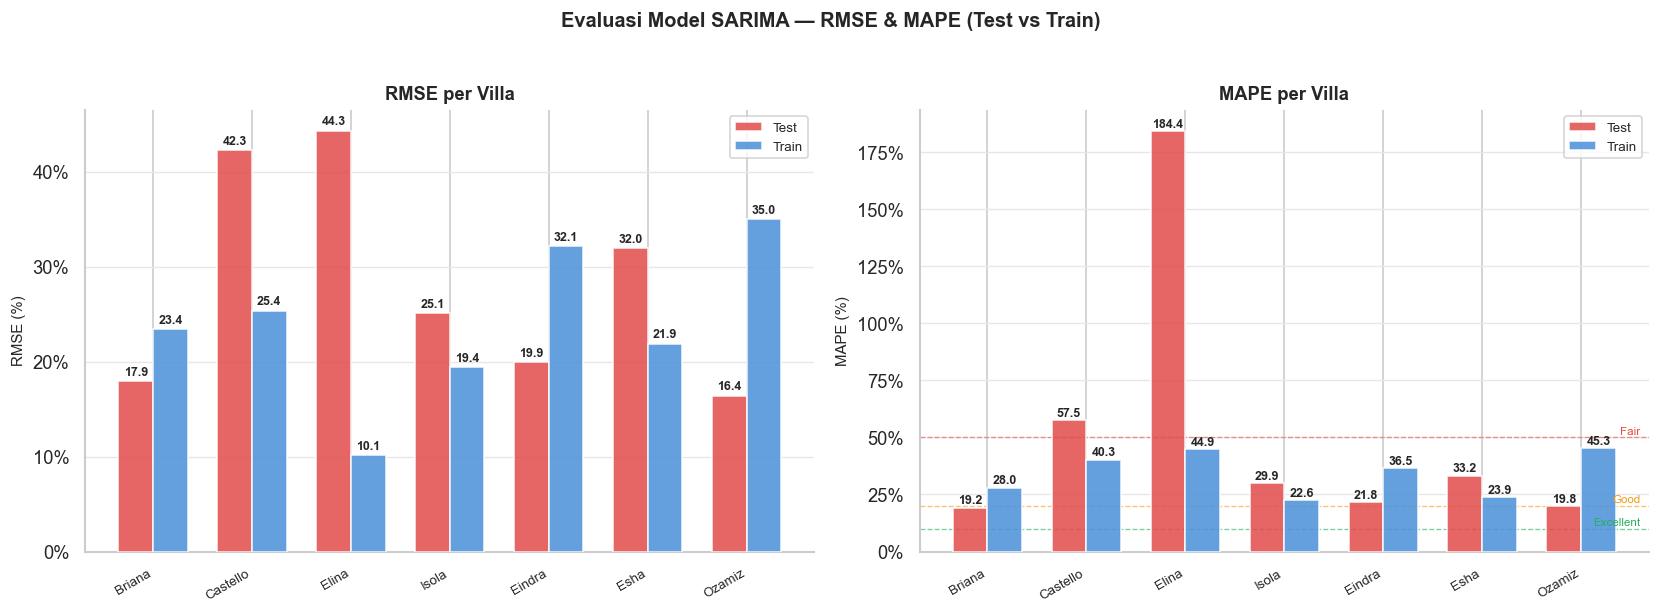

model_evaluation_rmse_mape.png tersimpan.

Semua detail per bulan (Train & Test) tersimpan di "semua_detail_evaluasi.csv".


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ---------------------------------------------------------------------
# 1. Definisi fungsi metrik (sesuai rumus manual)
# ---------------------------------------------------------------------

def calculate_rmse(actual, predicted):
    """
    RMSE = sqrt( 1/n * sum(yi - y_hat_i)^2 )
    Menerima list, Series, atau ndarray.
    """
    y  = np.array(actual,    dtype=float)
    yh = np.array(predicted, dtype=float)
    return np.sqrt(np.mean((y - yh) ** 2))


def calculate_mape(actual, predicted):
    """
    MAPE = 1/n * sum |( yi - y_hat_i ) / yi| * 100%
    Baris dengan yi = 0 diabaikan agar tidak terjadi pembagian dengan nol.
    """
    y  = np.array(actual,    dtype=float)
    yh = np.array(predicted, dtype=float)
    mask = y != 0                          # abaikan yi = 0
    return np.mean(np.abs((y[mask] - yh[mask]) / y[mask])) * 100


# ---------------------------------------------------------------------
# 2. Tabel detail per bulan (untuk verifikasi / laporan)
# ---------------------------------------------------------------------

def build_detail_table(actual_series, pred_array, label='Test'):
    """
    Buat tabel detail seperti tabel manual:
      Bulan | Aktual | Prediksi | Error | Error^2 | |Error/Aktual|x100%
    ditambah baris Jumlah, RMSE, dan MAPE.

    Parameters
    ----------
    actual_series : pd.Series  (index bertipe DatetimeIndex)
    pred_array    : array-like dengan panjang yang sama
    label         : str, hanya untuk header print

    Returns
    -------
    df_detail : pd.DataFrame  (termasuk baris ringkasan)
    rmse      : float
    mape      : float
    """
    y  = actual_series.values.astype(float)
    yh = np.array(pred_array, dtype=float)

    errors     = y - yh
    errors_sq  = errors ** 2
    abs_pct    = np.where(y != 0, np.abs(errors / y) * 100, np.nan)

    df = pd.DataFrame({
        'Bulan'              : actual_series.index.strftime('%b %Y'),
        'Aktual y_i (%)'     : np.round(y,  2),
        'Prediksi ŷ_i (%)'   : np.round(yh, 2),
        'Error (y_i − ŷ_i)' : np.round(errors,    4),
        'Error²'             : np.round(errors_sq, 4),
        '|Error/y_i|×100%'   : np.round(abs_pct,  2),
    })

    n          = len(df)
    sum_sq     = errors_sq.sum()
    sum_apct   = np.nansum(abs_pct)
    rmse_val   = np.sqrt(sum_sq / n)
    mape_val   = sum_apct / n

    row_sum = {
        'Bulan'              : 'Jumlah',
        'Aktual y_i (%)'     : '—',
        'Prediksi ŷ_i (%)'   : '—',
        'Error (y_i − ŷ_i)' : '—',
        'Error²'             : round(sum_sq,   4),
        '|Error/y_i|×100%'   : f'{sum_apct:.2f}%',
    }

    row_rmse = {
        'Bulan'              : 'RMSE',
        'Aktual y_i (%)'     : '—',
        'Prediksi ŷ_i (%)'   : '—',
        'Error (y_i − ŷ_i)' : '—',
        'Error²'             : (
            f'sqrt(1/{n} * {sum_sq:.4f})'
            f' = sqrt{sum_sq/n:.4f}'
            f' = {rmse_val:.2f}%'
        ),
        '|Error/y_i|×100%'   : '—',
    }

    row_mape = {
        'Bulan'              : 'MAPE',
        'Aktual y_i (%)'     : '—',
        'Prediksi ŷ_i (%)'   : '—',
        'Error (y_i − ŷ_i)' : '—',
        'Error²'             : '—',
        '|Error/y_i|×100%'   : (
            f'1/{n} * {sum_apct:.2f}'
            f' = {mape_val:.2f}%'
        ),
    }

    df_detail = pd.concat(
        [df,
         pd.DataFrame([row_sum]),
         pd.DataFrame([row_rmse]),
         pd.DataFrame([row_mape])],
        ignore_index=True
    )
    return df_detail, round(rmse_val, 4), round(mape_val, 4)


# ---------------------------------------------------------------------
# 3. Loop evaluasi utama
# ---------------------------------------------------------------------

metrics_rows  = []
detail_store  = {}        # simpan tabel detail tiap villa

print('=' * 80)
print('EVALUASI MODEL SARIMA: RMSE & MAPE')
print('=' * 80)

for villa, info in sarima_models.items():
    title = villa.replace('_villas', '').title()
    area  = VILLA_CONFIG[villa]['area'].title()

    # Test set
    tbl_test, rmse_t, mape_t = build_detail_table(
        info['test'], info['pred_mean'], label='Test'
    )
    detail_store[f'{title} — Test'] = tbl_test

    # Train set
    tbl_train, rmse_tr, mape_tr = build_detail_table(
        info['train'], info['train_fitted'], label='Train'
    )
    detail_store[f'{title} — Train'] = tbl_train

    # Klasifikasi kualitas berdasarkan MAPE test
    quality = (
        'Excellent' if mape_t < 10 else
        'Good'      if mape_t < 20 else
        'Fair'      if mape_t < 50 else
        'Poor'
    )

    # Deteksi overfitting: RMSE test > 1.5x RMSE train
    overfit = 'Overfit' if rmse_t > rmse_tr * 1.5 else 'OK'

    metrics_rows.append({
        'Villa'        : title,
        'Area'         : area,
        'Model'        : f'SARIMA{info["order"]}×{info["seasonal_order"]}',
        'RMSE (Test)'  : round(rmse_t,  2),
        'MAPE (Test)'  : round(mape_t,  2),
        'RMSE (Train)' : round(rmse_tr, 2),
        'MAPE (Train)' : round(mape_tr, 2),
        'Kualitas'     : quality,
        'Overfit?'     : overfit,
    })

    print(f'\n{title} ({area})')
    print(f'   Model  : SARIMA{info["order"]}×{info["seasonal_order"]}')
    print(f'   Test   -> RMSE = {rmse_t:.2f}%   |  MAPE = {mape_t:.2f}%   |  {quality}')
    print(f'   Train  -> RMSE = {rmse_tr:.2f}%  |  MAPE = {mape_tr:.2f}%  |  {overfit}')


# ---------------------------------------------------------------------
# 4. Tampilkan tabel detail tiap villa (opsional, untuk laporan)
# ---------------------------------------------------------------------

for key, tbl in detail_store.items():
    print(f'\n{"-"*70}')
    print(f'  {key}')
    print(f'{"-"*70}')
    display(tbl)


# ---------------------------------------------------------------------
# 5. Ringkasan akhir & simpan CSV
# ---------------------------------------------------------------------

metrics_df = pd.DataFrame(metrics_rows).set_index('Villa')

print('\n' + '=' * 80)
print('RINGKASAN EVALUASI SEMUA VILLA')
print('=' * 80)
display(metrics_df)

avg_rmse_t  = metrics_df['RMSE (Test)'].mean()
avg_mape_t  = metrics_df['MAPE (Test)'].mean()
avg_rmse_tr = metrics_df['RMSE (Train)'].mean()
avg_mape_tr = metrics_df['MAPE (Train)'].mean()

print(f'\nRata-rata Test  -> RMSE = {avg_rmse_t:.2f}%  |  MAPE = {avg_mape_t:.2f}%')
print(f'Rata-rata Train -> RMSE = {avg_rmse_tr:.2f}% |  MAPE = {avg_mape_tr:.2f}%')

metrics_df.to_csv('model_evaluation_metrics_mape.csv')
print('\nmodel_evaluation_metrics_mape.csv tersimpan.')


# ---------------------------------------------------------------------
# 6. Plot perbandingan RMSE & MAPE (bar chart semua villa)
# ---------------------------------------------------------------------

villas = metrics_df.index.tolist()
x      = np.arange(len(villas))
w      = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE
ax = axes[0]
bars_t  = ax.bar(x - w/2, metrics_df['RMSE (Test)'],  w,
                 label='Test',  color='#E24B4A', alpha=0.85, zorder=3)
bars_tr = ax.bar(x + w/2, metrics_df['RMSE (Train)'], w,
                 label='Train', color='#4A90D9', alpha=0.85, zorder=3)

for bar in bars_t + bars_tr:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom',
            fontsize=7.5, fontweight='bold')

ax.set_title('RMSE per Villa', fontsize=11, fontweight='bold')
ax.set_ylabel('RMSE (%)', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(villas, rotation=30, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.grid(axis='y', color='#e5e7eb', lw=0.8)
ax.spines[['top','right']].set_visible(False)
ax.legend(fontsize=8)

# MAPE
ax = axes[1]
bars_t2  = ax.bar(x - w/2, metrics_df['MAPE (Test)'],  w,
                  label='Test',  color='#E24B4A', alpha=0.85, zorder=3)
bars_tr2 = ax.bar(x + w/2, metrics_df['MAPE (Train)'], w,
                  label='Train', color='#4A90D9', alpha=0.85, zorder=3)

for bar in bars_t2 + bars_tr2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom',
            fontsize=7.5, fontweight='bold')

# Garis acuan kualitas MAPE
for level, lbl, clr in [(10,'Excellent','#27ae60'),
                         (20,'Good',     '#f39c12'),
                         (50,'Fair',     '#e74c3c')]:
    ax.axhline(level, ls='--', lw=0.8, color=clr, alpha=0.6)
    ax.text(len(villas)-0.4, level+0.5, lbl, fontsize=7,
            color=clr, va='bottom', ha='right')

ax.set_title('MAPE per Villa', fontsize=11, fontweight='bold')
ax.set_ylabel('MAPE (%)', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(villas, rotation=30, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.grid(axis='y', color='#e5e7eb', lw=0.8)
ax.spines[['top','right']].set_visible(False)
ax.legend(fontsize=8)

plt.suptitle('Evaluasi Model SARIMA — RMSE & MAPE (Test vs Train)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_evaluation_rmse_mape.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()
print('model_evaluation_rmse_mape.png tersimpan.')

all_details = pd.concat(detail_store.values(), keys=detail_store.keys())
all_details.to_csv('semua_detail_evaluasi.csv')
print('\nSemua detail per bulan (Train & Test) tersimpan di "semua_detail_evaluasi.csv".')

## 12. Diagnostik Residual — Ljung-Box

Lag Ljung-Box dibuat dinamis (`min(m, len(data)//3)`) agar tidak crash untuk data pendek.

In [20]:
diag_results = []

for villa, info in sarima_models.items():
    fitted = info['model']
    order  = info['order']
    s_ord  = info['seasonal_order']
    title  = villa.replace('_villas','').title()
    color  = VILLA_CONFIG[villa]['color']
    resid  = fitted.resid.dropna()
    m_val  = info['m']

    # Lag dinamis mengikuti panjang data
    lb_lag = max(3, min(m_val, len(resid) // 3))
    lb     = acorr_ljungbox(resid, lags=[lb_lag, lb_lag * 2], return_df=True)
    p_lb1  = float(lb['lb_pvalue'].iloc[0])
    p_lb2  = float(lb['lb_pvalue'].iloc[-1])
    lb_ok  = p_lb1 > 0.05
    status = 'Residual bersih' if lb_ok else 'Ada autokorelasi'

    _, p_norm = stats.shapiro(resid[:50])

    diag_results.append({
        'Villa'      : title,
        'Order'      : f'SARIMA{order}×{s_ord}',
        f'LB p(lag{lb_lag})' : round(p_lb1, 4),
        f'LB p(lag{lb_lag*2})': round(p_lb2, 4),
        'Ljung-Box'  : status,
        'Shapiro p'  : round(p_norm, 4),
        'Normalitas' : 'Normal' if p_norm > 0.05 else 'Non-normal',
    })

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    axes[0].plot(resid.index, resid.values, color=color, lw=1.2)
    axes[0].axhline(0, color='gray', ls='--', lw=0.8)
    axes[0].set_title(f'{title} | Residual over Time', fontsize=9)

    axes[1].hist(resid, bins=20, color=color, alpha=0.7, edgecolor='white')
    x_r = np.linspace(resid.min(), resid.max(), 100)
    axes[1].plot(x_r, stats.norm.pdf(x_r, resid.mean(), resid.std())
                 * len(resid) * (resid.max() - resid.min()) / 20, 'k--', lw=1.2)
    axes[1].set_title('Distribusi Residual', fontsize=9)

    stats.probplot(resid, dist='norm', plot=axes[2])
    axes[2].set_title('Q-Q Plot', fontsize=9)
    axes[2].get_lines()[0].set_color(color)

    for ax in axes:
        ax.grid(alpha=0.2); ax.spines[['top','right']].set_visible(False)

    plt.suptitle(f'{title} | {status} | LB-lag{lb_lag} p={p_lb1:.3f} | Shapiro p={p_norm:.3f}',
                 fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'residual_{villa}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'  [{title}] {status}')

print('\nRINGKASAN DIAGNOSTIK')
print('=' * 80)
display(pd.DataFrame(diag_results))

KeyError: 'm'